<h1><center><font size="6">Proyecto 03 - Flujo Vehicular por peajes AUSA</font></center></h1>

El objetivo del proyecto es estimar la demanda de la autopista Illia para el ultimo trimestre del 2019, medida en cantidad de pasos de vehiculos, mediante modelos predictivos de series de tiempo. Para ese fin, trabajaremos con los datos de 2017 al 2019, para esa estación de peaje y ese medio de pago.

La estrategia consiste en evaluar el desempeño de distintos modelos mediante el RMSE. En todos los casos, hablamos de modelos univariados, dónde la variable independiente es el tiempo, y la variable dependiente son la cantidad de pasos (cantidad de vehiculos que han pasado por el peaje).

# <a id='0'>Tabla de Contenidos</a>

1. [Identificación del problema](#setup1)<br>
2. [Exploración de datos](#explore)<br>
    2.1 [Acondicionamiento](#explore1)<br>
    2.2 [Análisis de Exploratorio de Datos (EDA)](#explore2)<br>
    2.3 [Tendencia, Estacionalidad y Ruido](#explore3)<br>
    2.4 [Autocorrelacion y Autocorrelacion parcial](#explore4)<br>
3. [Modelos](#modeling)<br>
    3.1 [Modelo Benchmark](#modeling1)<br>
    3.2 [Modelo ARIMA](#modeling2)<br>
4. [Próximos pasos](#prox)<br>
5. [Conclusiones](#con)<br>

## 1. Identificación del problema<a id="setup1"></a>

Utilizar la información del sistema de peajes de Buenos Aires de múltiples años e implementar un modelo que prediga el tráfico en las autopistas para el cuarto trimestre del 2019. La base de datos a utiliziar, Flujo Vehicular por Unidades de Peaje AUSA, se puede descargar en: [link](https://data.buenosaires.gob.ar/dataset/flujo-vehicular-por-unidades-peaje-ausa). 

In [1]:
# Librerías necesarias para el proyecto
import pandas as pd # facilitar el manejo de datos
import numpy as np # facilitar operaciones matriciales
import matplotlib.pyplot as plt # visualización
import seaborn as sns # mejorar estilo de visuales
import datetime # manejo de variables tipo fecha 
import gc # limpieza de variables inutilizadas

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
gc.enable() # activar limpieza automática de memoria

In [4]:
# Carga de datos de flujo vehicular en Buenos Aires
data_2019 = pd.read_csv('data/flujo-vehicular-2019.csv', sep =',') #2019
data_2018 = pd.read_csv('data/flujo-vehicular-2018.csv', sep =',') #2018
data_2017 = pd.read_csv('data/flujo-vehicular-2017.csv', sep =',') #2017

In [5]:
# Revisión de los datos cargados
data_2019.head()

,periodo,fecha,hora_inicio,hora_fin,dia,estacion,sentido,tipo_vehiculo,forma_pago,cantidad_pasos
0,2019,2019-01-01,0,1,Martes,Alberti,Centro,Liviano,NO COBRADO,22
1,2019,2019-01-01,0,1,Martes,Alberti,Centro,Liviano,TELEPASE,6
2,2019,2019-01-01,0,1,Martes,Alberti,Provincia,Liviano,NO COBRADO,53
3,2019,2019-01-01,0,1,Martes,Alberti,Provincia,Liviano,TELEPASE,18
4,2019,2019-01-01,0,1,Martes,Avellaneda,Centro,Liviano,EFECTIVO,16


In [6]:
data_2018.head()

,periodo,fecha,hora_inicio,hora_fin,dia,estacion,sentido,tipo_vehiculo,forma_pago,cantidad_pasos
0,2018,2018-01-01,0,1,Lunes,Alberdi,Centro,Liviano,NO COBRADO,29
1,2018,2018-01-01,0,1,Lunes,Alberdi,Centro,Liviano,TELEPASE,9
2,2018,2018-01-01,1,2,Lunes,Alberdi,Centro,Liviano,NO COBRADO,73
3,2018,2018-01-01,1,2,Lunes,Alberdi,Centro,Liviano,TELEPASE,39
4,2018,2018-01-01,2,3,Lunes,Alberdi,Centro,Liviano,NO COBRADO,115


In [7]:
data_2017.head()

,periodo,fecha,hora_inicio,hora_fin,dia,estacion,sentido,tipo_vehiculo,forma_pago,cantidad_pasos
0,2017,2017-01-01,0,1,Domingo,Alberdi,Centro,Liviano,NO COBRADO,25
1,2017,2017-01-01,0,1,Domingo,Alberdi,Centro,Liviano,TELEPASE,7
2,2017,2017-01-01,1,2,Domingo,Alberdi,Centro,Liviano,NO COBRADO,5
3,2017,2017-01-01,1,2,Domingo,Alberdi,Centro,Liviano,EFECTIVO,2
4,2017,2017-01-01,1,2,Domingo,Alberdi,Centro,Liviano,EFECTIVO,94


In [8]:
data_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812153 entries, 0 to 812152
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   periodo         812153 non-null  int64 
 1   fecha           812153 non-null  object
 2   hora_inicio     812153 non-null  int64 
 3   hora_fin        812153 non-null  int64 
 4   dia             812153 non-null  object
 5   estacion        812153 non-null  object
 6   sentido         812153 non-null  object
 7   tipo_vehiculo   812153 non-null  object
 8   forma_pago      812153 non-null  object
 9   cantidad_pasos  812153 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 62.0+ MB


In [9]:
data_2018.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375908 entries, 0 to 1375907
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   periodo         1375908 non-null  int64 
 1   fecha           1375908 non-null  object
 2   hora_inicio     1375908 non-null  int64 
 3   hora_fin        1375908 non-null  int64 
 4   dia             1375908 non-null  object
 5   estacion        1375908 non-null  object
 6   sentido         1375908 non-null  object
 7   tipo_vehiculo   1375908 non-null  object
 8   forma_pago      1375908 non-null  object
 9   cantidad_pasos  1375908 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 105.0+ MB


In [10]:
data_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372645 entries, 0 to 1372644
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   periodo         1372645 non-null  int64 
 1   fecha           1372645 non-null  object
 2   hora_inicio     1372645 non-null  int64 
 3   hora_fin        1372645 non-null  int64 
 4   dia             1372645 non-null  object
 5   estacion        1372645 non-null  object
 6   sentido         1372645 non-null  object
 7   tipo_vehiculo   1372645 non-null  object
 8   forma_pago      1372645 non-null  object
 9   cantidad_pasos  1372645 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 104.7+ MB


Todos los datasets tienen la misma cantidad de columnas con los mismos nombres y no contienen a primera vista datos faltantes, al menos en el formato "np.nan".

<a href="#0"><font size="1">Back to contents</font></a>

## 2. Exploración de datos<a id="explore"></a>

Para la exploración de datos revisamos en primer lugar las distintas columnas que contienen los datasets.

* Estación

In [11]:
print("Estaciones en 2019:", data_2019['estacion'].unique())
print("Estaciones en 2018:", data_2018['estacion'].unique())
print("Estaciones en 2017:", data_2017['estacion'].unique())

Estaciones en 2019: ['Alberti' 'Avellaneda' 'Dellepiane' 'Illia' 'Retiro' 'Salguero'
 'Sarmiento' 'PDB']
Estaciones en 2018: ['Alberdi' 'Avellaneda' 'Dellepiane Centro' 'Dellepiane Liniers' 'Illia'
 'Retiro' 'Salguero' 'Sarmiento']
Estaciones en 2017: ['Alberdi' 'Avellaneda' 'Dellepiane Centro' 'Dellepiane Liniers' 'Illia'
 'Retiro' 'Salguero' 'Sarmiento']


Observando el listado de estaciones se encuentra que los años 2017 y 2018 tienen la misma cantidad e igual nombres en las estaciones, y por otra parte los datos del 2019 incluyen una nueva estación que al investigar corresponde a Paso del Bajo [link](https://www.estadisticaciudad.gob.ar/eyc/?p=41995). Esta nueva estación arrancó operaciones en Mayo del 2019. 

Adicionalmente Alberti, Avellaneda, Dellepiane e Illia empezaron funcionamiento en Enero del 2014, seguidas por las estaciones de Retiro en Junio del 2014, Sarmiento en Julio del 2014 y Salguero en Julio del 2015.  

* Sentido

In [12]:
print("Sentido 2019:", data_2019['sentido'].unique())
print("Sentido 2018:", data_2018['sentido'].unique())
print("Sentido 2017:", data_2017['sentido'].unique())

Sentido 2019: ['Centro' 'Provincia']
Sentido 2018: ['Centro' 'Provincia']
Sentido 2017: ['Centro' 'Provincia']


Los datasets tienen dos posibles valores en la columna sentido, Centro o Provincia.

* Tipo de vehículo

In [13]:
print("Tipo de Vehiculo 2019:", data_2019['tipo_vehiculo'].unique())
print("Tipo de Vehiculo 2018:", data_2018['tipo_vehiculo'].unique())
print("Tipo de Vehiculo 2017:", data_2017['tipo_vehiculo'].unique())

Tipo de Vehiculo 2019: ['Liviano' 'Pesado']
Tipo de Vehiculo 2018: ['Liviano' 'Pesado']
Tipo de Vehiculo 2017: ['Liviano' 'Pesado']


* Forma de pago

In [14]:
print("Forma de pago 2019:", data_2019['forma_pago'].unique())
print("Forma de pago 2018:", data_2018['forma_pago'].unique())
print("Forma de pago 2017:", data_2017['forma_pago'].unique())

Forma de pago 2019: ['NO COBRADO' 'TELEPASE' 'EFECTIVO' 'EXENTO' 'INFRACCION'
 'T. DISCAPACIDAD']
Forma de pago 2018: ['NO COBRADO' 'TELEPASE' 'EFECTIVO' 'EXENTO' 'TARJETA DISCAPACIDAD'
 'INFRACCION']
Forma de pago 2017: ['NO COBRADO' 'TELEPASE' 'EFECTIVO' 'TARJETA DISCAPACIDAD' 'EXENTO'
 'INFRACCION' 'MONEDERO' 'Otros']


Se nota que el dataset del 2019 contiene tarjeta de discapacidad escrita de otra forma y por su parte el dataset del 2017 incluye monedero y otros que no se muestran en los datos de 2018 y 2019.

**De acuerdo a esta primera exploracion los datasets de 2017, 2018 y 2019 no tienen valores faltantes y los 3 los tienen las mismas columnas las cuales contienen la siguiente información:**

- **periodo:** Año del dataset
- **fecha:** Año - Dia - Mes
- **hora_inicio:** hora de inicio de la cuenta de vehiculos
- **hora_fin** hora de fin de la cuenta de vehiculos (Vamos a usar esta para tomar la hora)
- **dia**: dia de la semana 
- **estacion**: Alberti, Avellaneda, Dellepiane Centro, Dellepiane Liniers, Illia, Retiro, Salguero o Sarmiento. En los dataset de 2017 y 2018 se encuentra la estacion "Alberdi" y en el 2019 "Alberti", en el dataset de 2019 se encuentra solo Dellepiane y se agrega Paso del Bajo (PDB).
- **sentido**: Centro o Provincia
- **tipo_vehiculo**: Liviano o Pesado
- **forma_pago**: Hay varias y varian entre los años. En el dataset de 2019 se encuentra una entrada "T. DISCAPACIDAD" equivalente a "TARJETA DISCAPACIDAD" que se encuentra en los dataset de 2017 y 2018.
- **cantidad_pasos**: Cantidad de vehiculos

<a href="#0"><font size="1">Volver a contenidos</font></a>

### 2.1. Acondicionamiento<a id="explore1"></a>

1. Concatenar los 3 dataset.
2. Unificar fecha - hora y transformar el tipo de dato datetime, para ello se tendra en cuenta la hora de fin.
3. Eliminar columnas innecesarias "hora_inicio" y "hora_fin".
4. Cambiar en la columna de estación las entradas "Alberdi" a "Alberti".
5. Cambiar en la columna de estación las entradas "Dellepiane Liniers" o "Dellepeine Centro" a "Dellepeine"
6.  Cambiar en la columna de forma de pago las entradas "T. DISCAPACIDAD" a "TARJETA DISCAPACIDAD".

In [15]:
# 1. Concatenar los data sets
# Unimos los 3 datasets, ya que tienen las mismas columnas
peajes = pd.concat([data_2019, data_2018, data_2017])
# 2. Unificar fecha
# Pasamos la columna fecha a formato datetime, y le unimos la hora_fin como hora
peajes['fecha2'] = pd.to_datetime(peajes.fecha) + pd.to_timedelta(peajes.hora_fin, unit = 'h')
# 3. Eliminar periodo y hora
peajes.drop(columns= ['hora_inicio','hora_fin', 'fecha'],inplace=True)
peajes.rename(columns={'fecha2':'fecha'}, inplace=True)
# 4. Arreglar nombres estaciones
# Arreglar el error de escritura de la estacion Alberti
peajes['estacion']= peajes['estacion'].apply(lambda x: "Alberti" if x=='Alberdi' else x) 
# 5. Arreglar nombres estaciones
# Estaciones Dellepiane Centro y Dellepiane Liniers transformadas a Dellepiane
peajes['estacion']= peajes['estacion'].apply(lambda x: "Dellepiane" if (x=='Dellepiane Liniers')|(x=='Dellepiane Centro') else x)
# 6. Arreglar forma de pago
peajes['forma_pago']= peajes['forma_pago'].apply(lambda x: "TARJETA DISCAPACIDAD" if x=='T. DISCAPACIDAD' else x)  

In [16]:
# Mezcla de datasets
peajes.head(2)

,periodo,dia,estacion,sentido,tipo_vehiculo,forma_pago,cantidad_pasos,fecha
0,2019,Martes,Alberti,Centro,Liviano,NO COBRADO,22,2019-01-01 01:00:00
1,2019,Martes,Alberti,Centro,Liviano,TELEPASE,6,2019-01-01 01:00:00


In [17]:
# Cantidad de filas y columnas resultantes
peajes.shape

(3560706, 8)

<a href="#0"><font size="1">Volver a contenidos</font></a>

### 2.2. Análisis de Exploratorio de Datos (EDA)<a id="explore2"></a>

### 2.2.1. EDA - Todas las estaciones

### Rangos de fechas de operación

In [18]:
# Crear un data set con los limites de fecha para cada estación
estaciones= peajes.groupby(['estacion']).fecha.min().rename_axis('estacion').reset_index(name='fecha min')
estaciones['fecha max']= peajes.groupby(['estacion']).fecha.max().values
estaciones

,estacion,fecha min,fecha max
0,Alberti,2017-01-01,2019-12-31 23:00:00
1,Avellaneda,2017-01-01,2019-12-31 23:00:00
2,Dellepiane,2017-01-01,2019-12-31 23:00:00
3,Illia,2017-01-01,2019-12-31 23:00:00
4,PDB,2019-01-06,2019-12-31 23:00:00
5,Retiro,2017-01-01,2019-12-31 23:00:00
6,Salguero,2017-01-01,2019-12-31 23:00:00
7,Sarmiento,2017-01-01,2019-12-31 23:00:00


Esta tabla nos muestra el rango de tiempos en la operación de las estaciones de peajes. Paso del Bajo, PDB, se destaca por tener como fecha inicial o mínima el seis de Enero del 2019, mientras que las otras estaciones tienen datos desde el primero de enero del 2017.

### Flujo Vehicular por estación

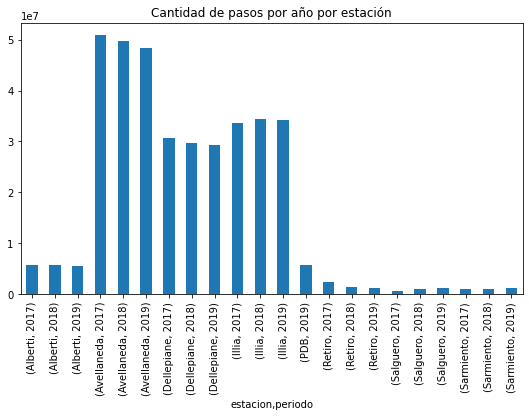

In [19]:
plt.figure(figsize=(9,5))
peajes.groupby(['estacion', 'periodo'])['cantidad_pasos'].sum().plot(kind='bar')
plt.title("Cantidad de pasos por año por estación")
plt.show()

Se observa en la gráfica estaciones que las estaciones comparten el mismo rango de fechas excepto por PDB la cual fue añadida en 2019. Al observar el grafico de barras:
- Se puede ver como Avellaneda, Dellepeine y Illia tienen mayor flujo de vehiculos.
- Alberti y Sarmiento han mantenido un flujo constante de vehiculos por año.
- Avellaneda, Dellepeine y Retiro el flujo de vehiculos ha descendido.
- El flujo vehicular de Salguero ha incrementado año a año.
- Illia no es muy claro si aumentara o decrecera el flujo vehicular el siguiente año.
- PDB es la estacion que añadieron en el 2019, por tanto no se tiene mucha información para detarminar que sucedería en el futuro.

### Formas de pago

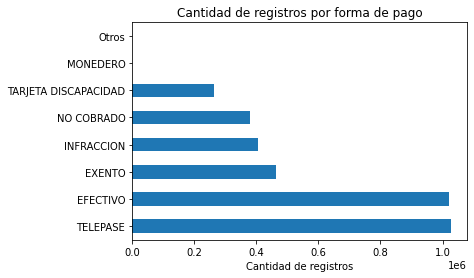

In [20]:
# Un registro tiene múltiples cantidades de paso
peajes['forma_pago'].value_counts().plot(kind='barh')
plt.title("Cantidad de registros por forma de pago")
plt.xlabel("Cantidad de registros")
plt.show()

Los vehiculos que más suelen transitar por los peajes pagan con efectivo o telepase.

### Análisis de comprotamiento por mes, semana y día para todas las estaciones

* Mes vs cantidad de pasos vehiculares

In [21]:
# Crear la variable mes año
peajes['mes_ano']= pd.to_datetime(peajes.fecha).dt.to_period("M")

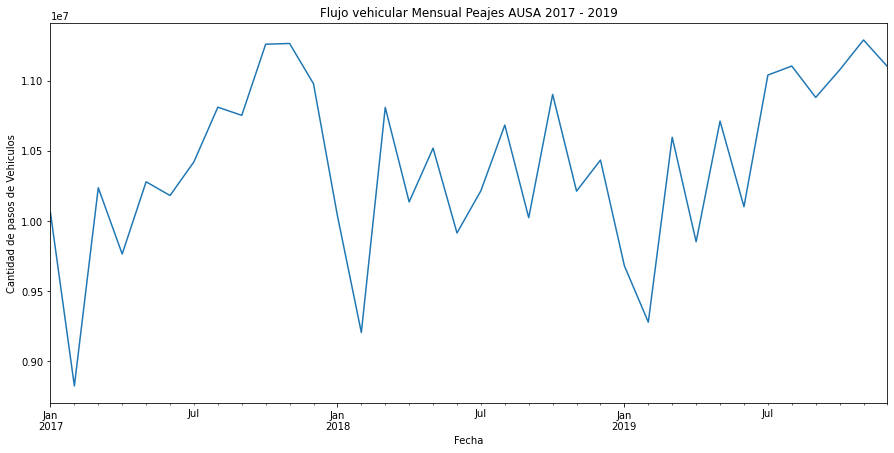

In [22]:
fig= plt.figure(figsize=(15,7))
peajes.groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
plt.title("Flujo vehicular Mensual Peajes AUSA 2017 - 2019")
plt.ylabel("Cantidad de pasos de Vehiculos")
plt.xlabel("Fecha")
plt.show()

Entre Enero - Febrero marca los puntos más bajos de cantidad de pasos vehiculares para los tres años.

* Día de la semana vs cantidad de pasos vehiculares

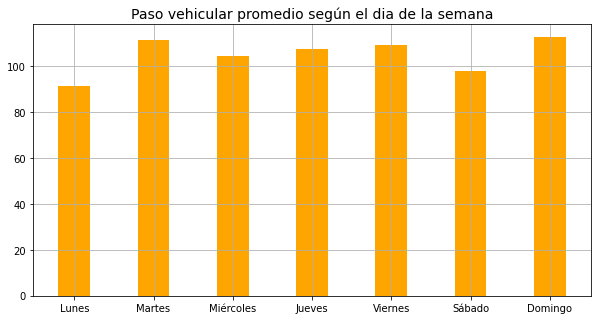

In [23]:
fig= plt.figure(figsize=(10,5))
paso_diario = peajes.groupby(['dia'])['cantidad_pasos'].mean()
ax = plt.subplot(1,1,1)
x_value=[2*e + 0.81 for e in range(7)]
plt.bar(x_value,paso_diario,color='orange')
days_of_week=['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
ax.set_xticks(x_value)
ax.set_xticklabels(days_of_week,rotation=0)
plt.title('Paso vehicular promedio según el dia de la semana',fontsize=14)
plt.grid()
plt.show()

El flujo vehicular de los martes es mayor a los otros días de la semana y similar al flujo del domingo, marcado como el mayor de todos. Recordar que está gráfica se hizo agrupando todos días entre 2017 - 2019.

* Por hora del día

In [24]:
# Creamos la variable hora
peajes['hora'] = pd.to_datetime(peajes.fecha).dt.hour

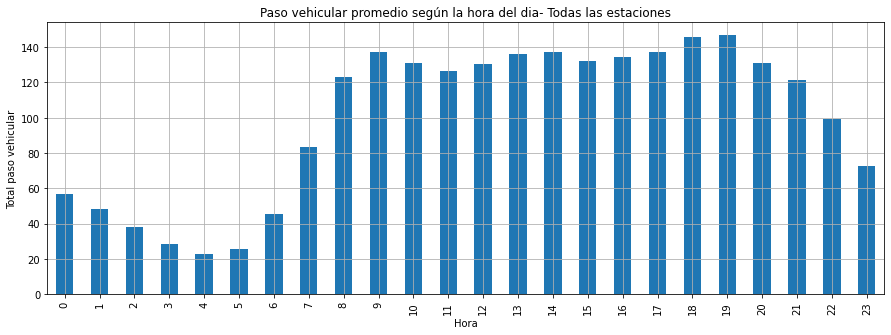

In [25]:
peajes.groupby(['hora'])['cantidad_pasos'].mean().plot(kind='bar', stacked=True, figsize=(15,5)) 
plt.title("Paso vehicular promedio según la hora del dia- Todas las estaciones")
plt.ylabel("Total paso vehicular")
plt.xlabel("Hora")
plt.grid()
plt.show()

Para todas las estaciones el mayor tráfico vehicular es mínimo a las 4 am y máximo a las 7 pm. La distribución parece bimodal, es seguro que cambie al analizar las estaciones por separado, ya que las estaciones con mayor tráfico vehicular arrastran el valor medio de tráfico.

In [26]:
# Data frame top 3 estaciones con mas flujo vehicular
top3estaciones = peajes[(peajes.estacion=='Illia')|(peajes.estacion=='Avellaneda')|(peajes.estacion=='Dellepiane')]

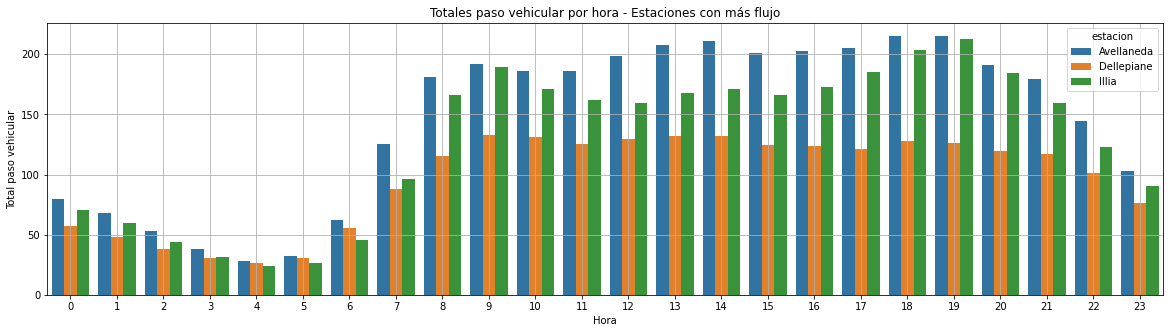

In [27]:
estacion_hora = top3estaciones.groupby(['estacion','hora'])['cantidad_pasos'].mean()
estacion_hora = estacion_hora.to_frame().reset_index()
estacion_hora = estacion_hora.rename(columns={0:'cantidad_pasos'})
plt.figure(figsize=(20,5))
sns.barplot(x='hora', y='cantidad_pasos', data= estacion_hora, hue='estacion')
plt.title("Totales paso vehicular por hora - Estaciones con más flujo")
plt.ylabel("Total paso vehicular")
plt.xlabel("Hora")
plt.grid()
plt.show()

El comportamiento general de todas las estaciones es similar al mostrado por Avellaneda, sin embargo Illia tiene un comportamiento similar al bimodal con dos máximos a las 9am y a las 7pm.  Por otra parte Dellepiane parece una meseta entre las 9am y las 9pm. Todas con mínimo global a las 4am.

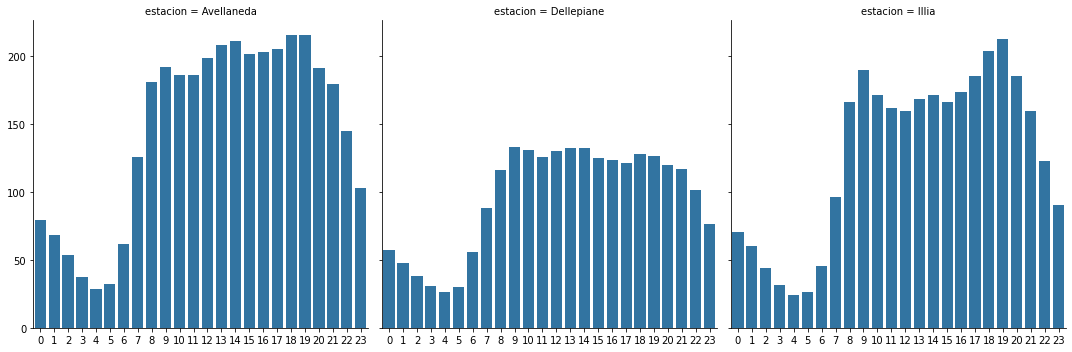

In [28]:
estacion_hora = top3estaciones.groupby(['estacion','hora'])['cantidad_pasos'].mean()
estacion_hora = estacion_hora.to_frame().reset_index()
estacion_hora = estacion_hora.rename(columns={0:'cantidad_pasos'})
g = sns.FacetGrid(estacion_hora, col="estacion",height=5)
g.map_dataframe(sns.barplot, x="hora", y='cantidad_pasos')
plt.show()

Avellaneda tiene el mayor flujo vehicular de las tres estaciones con mayor flujo. Adicionalmente, entre las 6 y las 8 incrementa en gran medida el flujo vehicular y entre las 8 a las 19 horas es relativamente constante. Y luego de las 19 horas decrece.

* Análisis diario y semanal

In [29]:
# Creación de las series diario y semanal
diario = peajes.resample('D', on= 'fecha').sum()
semanal = peajes.resample('W', on= 'fecha').sum()

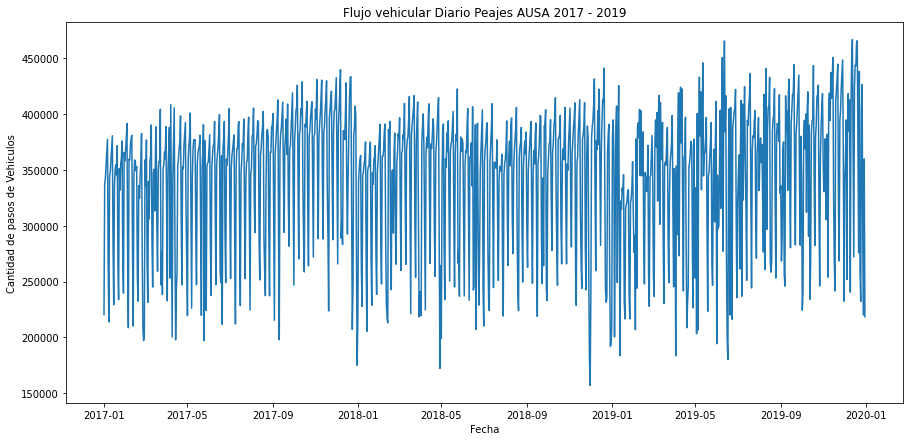

In [30]:
plt.figure(figsize=(15, 7))
plt.plot(diario.index, diario.cantidad_pasos)
plt.title("Flujo vehicular Diario Peajes AUSA 2017 - 2019")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de pasos de Vehiculos")
plt.show()

El flujo vehicular tiene una estacionalidad anual donde en los primeros meses se tiene el menor tráfico y va aumentando paulatinamente (recordar que entre Enero y Febrero hay el menor tráfico). El último año analizado tiene un comportamiento más variable/ ruidoso, lo que puede afectar las predicciones y hacen necesario una remoción de outliers.

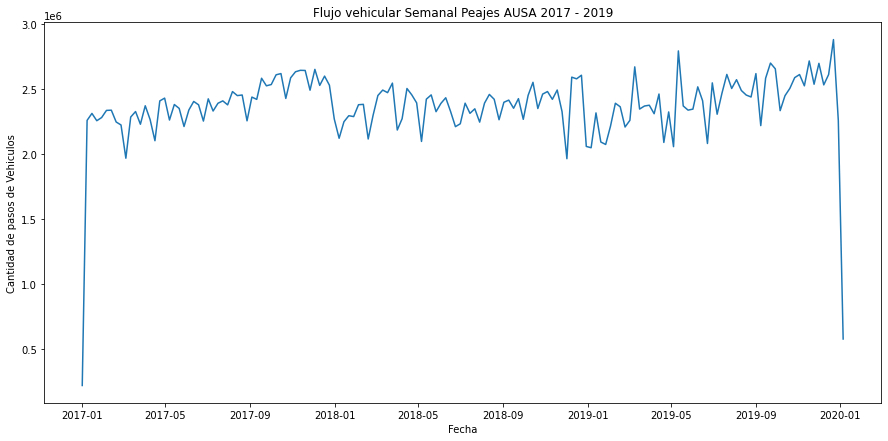

In [31]:
plt.figure(figsize=(15, 7))
plt.plot(semanal.index, semanal.cantidad_pasos)
plt.title("Flujo vehicular Semanal Peajes AUSA 2017 - 2019")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de pasos de Vehiculos")
plt.show()

El flujo vehicular semanal varía consistentemente entre 2 millones y 2.7 millones. Y se nota el incremento paulatino desde los inicios del año hacia el final de año.

<a href="#0"><font size="1">Volver a contenidos</font></a>

### 2.2.2. EDA - Estación Illia

Se elige esta estación ya que demuestra una tendencia aleatoria para el cuarto trimestre del año 2019.

In [32]:
# Data set exclusivo para la estacion Illia
illia = peajes[peajes.estacion=='Illia']
# Data frame
top2estaciones = peajes[(peajes.estacion=='Avellaneda')|(peajes.estacion=='Dellepiane')]

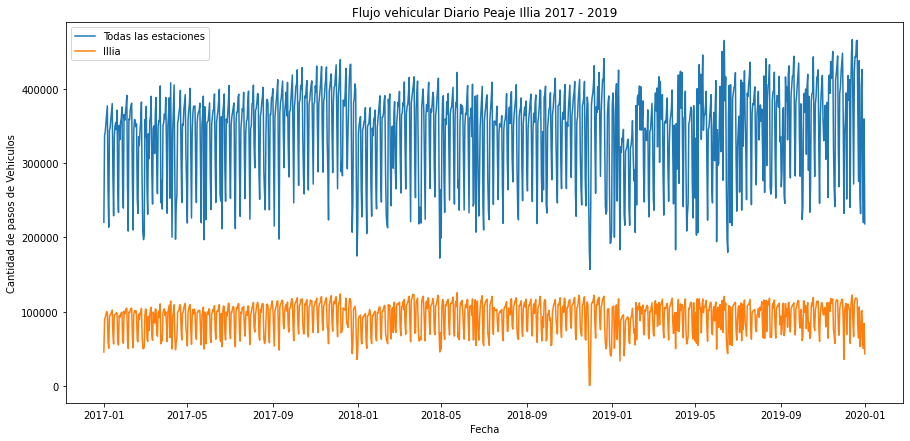

In [33]:
# Se crea la serie diaria de la estación Illia
diario_illia = illia.resample('D', on='fecha').sum()

plt.figure(figsize=(15, 7))
plt.plot(diario.index, diario.cantidad_pasos)
plt.plot(diario_illia.index, diario_illia.cantidad_pasos)
plt.title("Flujo vehicular Diario Peaje Illia 2017 - 2019")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de pasos de Vehiculos")
plt.legend(['Todas las estaciones','Illia'])
plt.show()

A primera vista, la tendencia de flujo vehicular es similar al compendio de estaciones y se nota una viariabilidad más baja ya que la gráfica azul contiene todas las estaciones y hay algunas donde tienen bajo flujo vehicular.

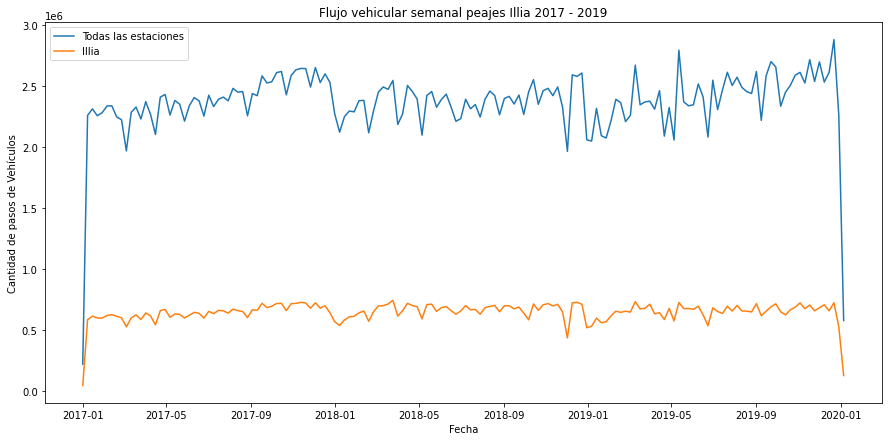

In [34]:
semanal_illia = illia.resample('W', on='fecha').sum()

plt.figure(figsize=(15, 7))
plt.plot(semanal.index, semanal.cantidad_pasos)
plt.plot(semanal_illia.index, semanal_illia.cantidad_pasos)
plt.title("Flujo vehicular semanal peajes Illia 2017 - 2019")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de pasos de Vehículos")
plt.legend(['Todas las estaciones','Illia'])
plt.show()

La variabilidad que para todas las estaciones era entre 2 a 2.7 millones, en el caso de Illia está entre 400 mil a 600 mil. La tendencia final de las gráficas se debe a que se visualiza como una semana incompleta o recortada.

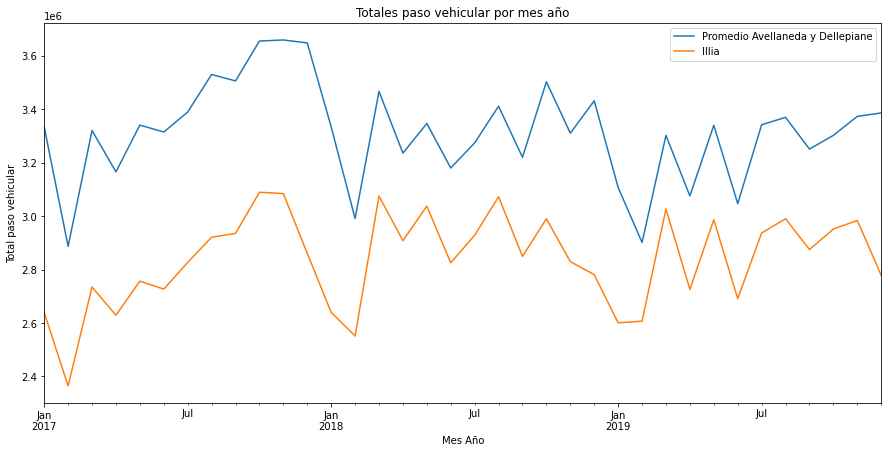

In [35]:
fig= plt.figure(figsize=(15,7))
(top2estaciones.groupby(['mes_ano'])['cantidad_pasos'].sum()/top2estaciones.estacion.nunique()).plot()
illia.groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
plt.title("Totales paso vehicular por mes año")
plt.ylabel("Total paso vehicular")
plt.xlabel("Mes Año")
plt.legend(['Promedio Avellaneda y Dellepiane','Illia'])
plt.show()

Ya que comparar a Illia con el total de estaciones puede ser algo brusco debido a que no todas las estaciones tienen un flujo vehicular similar, se realiza la comparación contra Avellaneda y Dellepiane que hacen parte con Illia de las 3 estaciones con más tráfico.

En esta gráfica se nota a primera vista que el promedio de tráfico es menor en Illia frente a las otras dos estaciones. Pero la estacionalidad es similar. 

* Distribución por mes

A continuacion agruparemos por mes el promedio de la cantidad de pasos para verificar la tendencia que estamos observando en donde los meses de enero-febrero se caracteriza por tener la menor cantidad de pasos y octubre-noviembre la mayor.

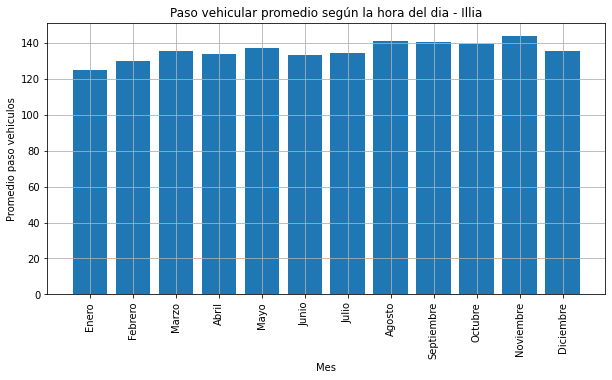

In [36]:
illia['mes'] = pd.to_datetime(illia.fecha).dt.month
illia.sort_values(by="mes", inplace=True, )
plt.figure(figsize=(10,5))
ax=plt.subplot(111)
meses=["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",\
      "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
mes_pasos = illia.groupby(['mes'])['cantidad_pasos'].mean().reset_index()
plt.bar(mes_pasos["mes"], mes_pasos["cantidad_pasos"])
ax.set_xticks(list(range(1,13)))
ax.set_xticklabels(meses, rotation=90)
plt.title("Paso vehicular promedio según la hora del dia - Illia")
plt.ylabel("Promedio paso vehiculos")
plt.xlabel("Mes")
plt.grid()
plt.show()

De acuerdo a lo visto se corrobora lo que observamos anteriormente y ademas vemos que en diciembre-enero decae la cantidad de vehiculos que pasan por el peaje, y que los meses desde agosto a noviembre se caracterizan por tener un alto flujo de vehiculos.

* Día de la semana vs cantidad de pasos vehiculares - Illia

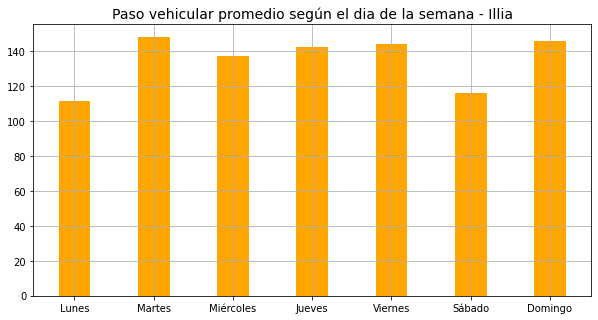

In [37]:
fig= plt.figure(figsize=(10,5))
paso_diario = illia.groupby(['dia'])['cantidad_pasos'].mean()
ax = plt.subplot(1,1,1)
x_value=[2*e + 0.81 for e in range(7)]
plt.bar(x_value,paso_diario,color='orange')
days_of_week=['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
ax.set_xticks(x_value)
ax.set_xticklabels(days_of_week,rotation=0)
plt.title('Paso vehicular promedio según el dia de la semana - Illia',fontsize=14)
plt.grid()
plt.show()

El martes es el dia que registra mayor flujo vehicular y es de sorprender quizas que el lunes y sabado sean los dias que menos vehiculos pasan por el peaje debido a que uno es dia laboral y el otro es un dia semifestivo y semilaboral donde se esperaria mayor actividad de transito.

* Por hora del día

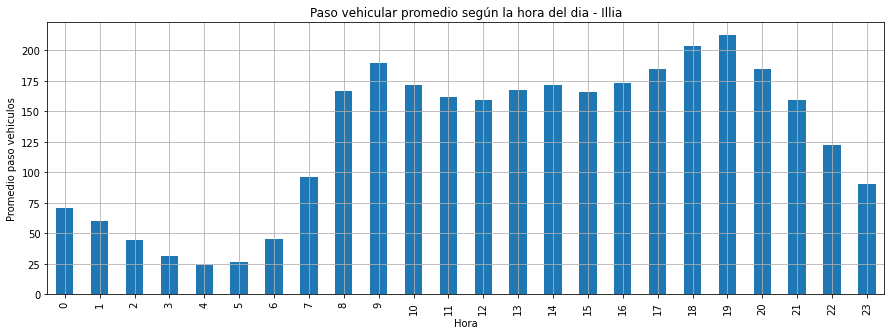

In [38]:
# Creamos la variable hora
illia = illia.copy()
illia['hora'] = pd.to_datetime(illia.fecha).dt.hour

illia.groupby(['hora'])['cantidad_pasos'].mean().plot(kind='bar', stacked=True, figsize=(15,5)) 
plt.title("Paso vehicular promedio según la hora del dia - Illia")
plt.ylabel("Promedio paso vehiculos")
plt.xlabel("Hora")
plt.grid()
plt.show()

Illia tiene un flujo vehicular por hora un poco distinto a las demás estaciones. Hay dos picos en la gráfica, uno a las 9 horas y otro a las 19 horas. Estos picos marcan lo que para muchos es el jornada laboral y entre ellas no se observa una disminucion apreciable del flujo, incluso se puede ver como el fluj vehicular desciende despues de las 19 horas hasta las 4 horas en donde comumente es la franja donde las personas dormimos y poco a poco aumenta a medida que las personas salen de sus hogares.

* Comparación de otras características entre todas las estaciones frente a Illia

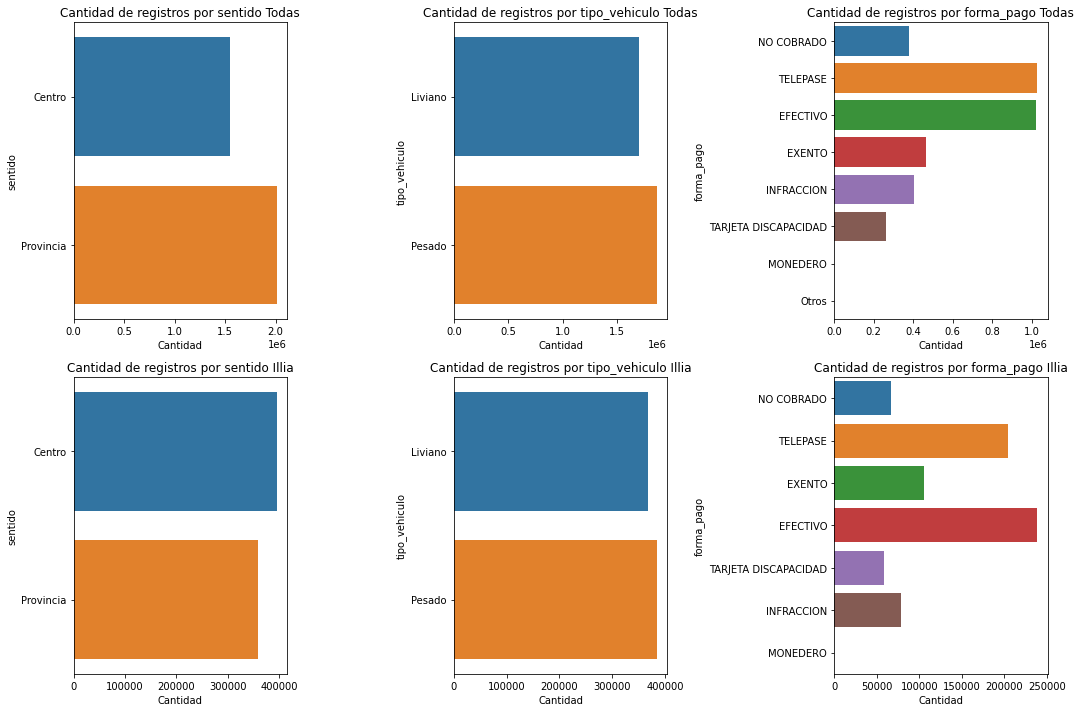

In [39]:
plt.figure(figsize=(15,10))
vars_to_plot= ['sentido','tipo_vehiculo','forma_pago']
for i, var in enumerate(vars_to_plot):
    plt.subplot(2,3,i+1)
    sns.countplot(y=var,data=peajes)
    plt.xlabel("Cantidad")
    plt.title(f"Cantidad de registros por {var} Todas") 
for i, var in enumerate(vars_to_plot):
    plt.subplot(2,3,3+i+1)
    sns.countplot(y=var,data=illia)
    plt.xlabel("Cantidad")
    plt.title(f"Cantidad de registros por {var} Illia") 
plt.tight_layout()
plt.show()

Hay mayor cantidad de registro en el sentido "Provincia" para el dataset general y en cambio, Illia posee una cantidad mayor para el sentido "Centro".

Adicionalmente Illia tiene mayor cantidad de flujo vehicular por efectivo que en telepase, en cuanto a tipo de vehiculo es similar.

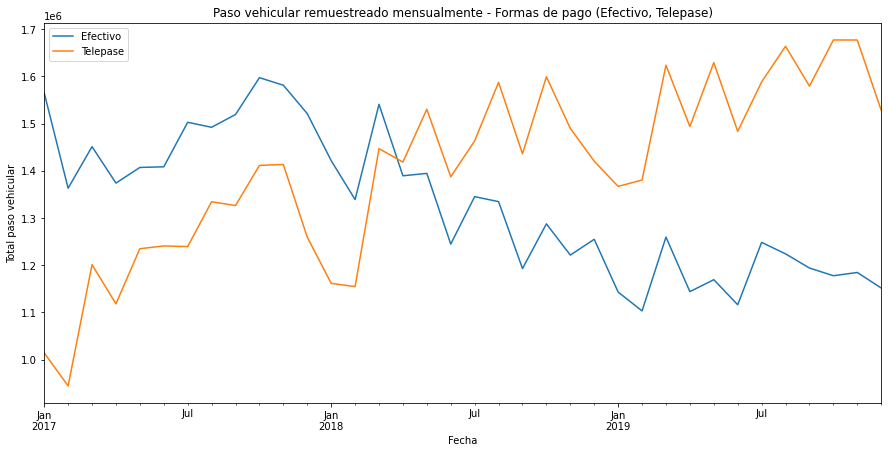

In [40]:
fig= plt.figure(figsize=(15,7))
illia[illia.forma_pago=='EFECTIVO'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
illia[illia.forma_pago=='TELEPASE'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
plt.title("Paso vehicular remuestreado mensualmente - Formas de pago (Efectivo, Telepase)")
plt.ylabel("Total paso vehicular")
plt.xlabel("Fecha")
plt.legend(['Efectivo','Telepase'])
plt.show()

A mediados del 2018 se observa que la forma de pago de telepase supera al efectivo y esta tendencia poco a poco se hace más fuerte, es decir el Telepase representa la mayor cantidad de flujo vehicular en los años más recientes.

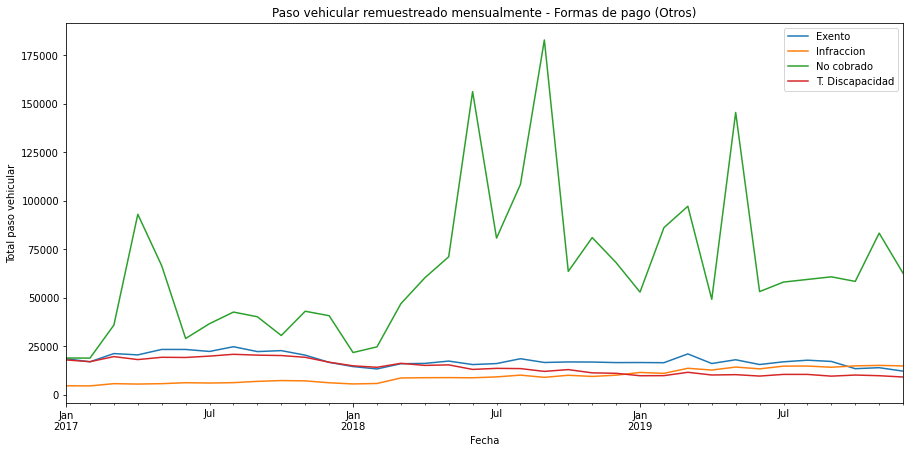

In [41]:
fig= plt.figure(figsize=(15,7))
illia[illia.forma_pago=='EXENTO'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
illia[illia.forma_pago=='INFRACCION'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
illia[illia.forma_pago=='NO COBRADO'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
illia[illia.forma_pago=='TARJETA DISCAPACIDAD'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
plt.title("Paso vehicular remuestreado mensualmente - Formas de pago (Otros)")
plt.ylabel("Total paso vehicular")
plt.xlabel("Fecha")
plt.legend(['Exento','Infraccion','No cobrado','T. Discapacidad'])
plt.show()

Analizando las formas de pago menos comunes, entre el 2018 y 2019 se observa una variabilidad grande en los no cobrados. Mientras que las infracciones tienen un incremento paulatino a diferencia de las tarjetas de discapacidad.  

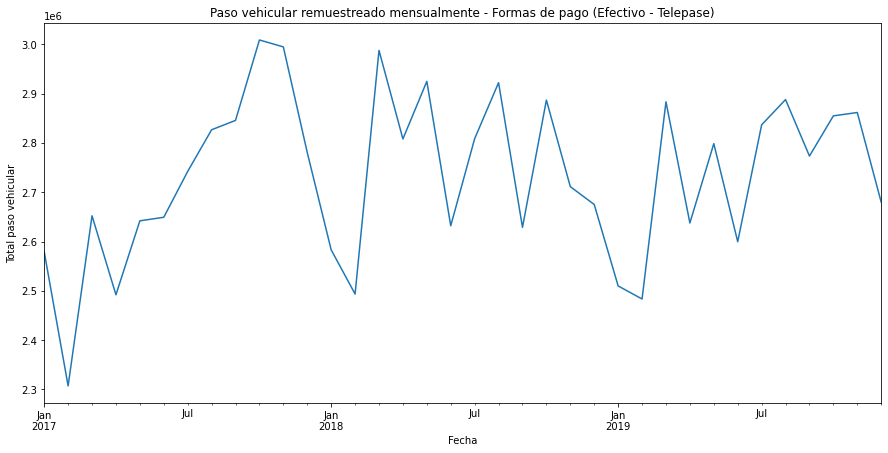

In [42]:
fig= plt.figure(figsize=(15,7))
illia[(illia.forma_pago=='EFECTIVO') | (illia.forma_pago=='TELEPASE')].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
plt.title("Paso vehicular remuestreado mensualmente - Formas de pago (Efectivo - Telepase)")
plt.ylabel("Total paso vehicular")
plt.xlabel("Fecha")
plt.show()

Tomando las dos formas de pago más recurrentes se observa alta variabilidad entre los meses, al considerar los datos remuestreados por mes.

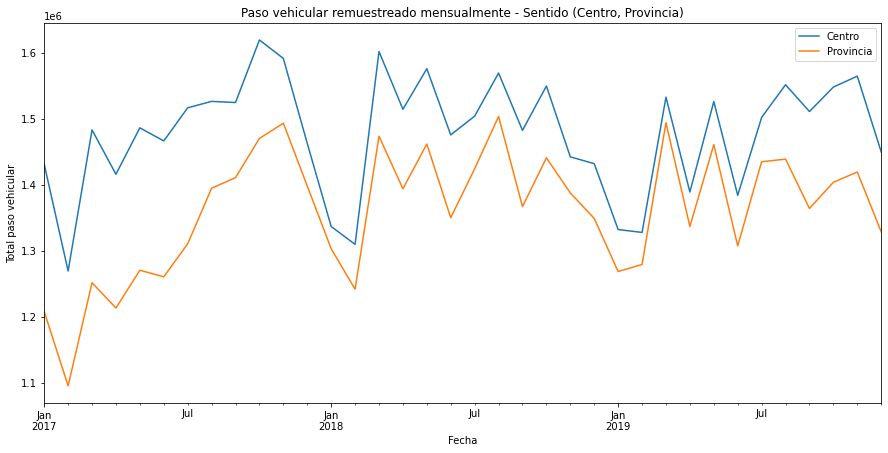

In [43]:
fig= plt.figure(figsize=(15,7))
illia[illia.sentido=='Centro'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
illia[illia.sentido=='Provincia'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
plt.title("Paso vehicular remuestreado mensualmente - Sentido (Centro, Provincia)")
plt.ylabel("Total paso vehicular")
plt.xlabel("Fecha")
plt.legend(['Centro','Provincia'])
plt.show()

Cuando vemos las 2 series es evidente que el sentido hacia el centro es el mas transitado en toda la serie, a pesar de que hay meses donde se cierra esta diferencia. Para nosotros es increíble encontrar estas diferencias porque en teoría deberían ser iguales en ambos sentidos e incluso se puede ver que el comportamiento de las 2 series es muy similar en sus aumentos y decrecimientos de flujo, algo que quizas no se note en la base de datos es el costo por el peaje, y quizas hacia el sentido Provincia sea más caro el peaje por lo cual los conductores opten por una via alterna, o existe una via alterna de fácil acceso que hace inviable pagar peaje.

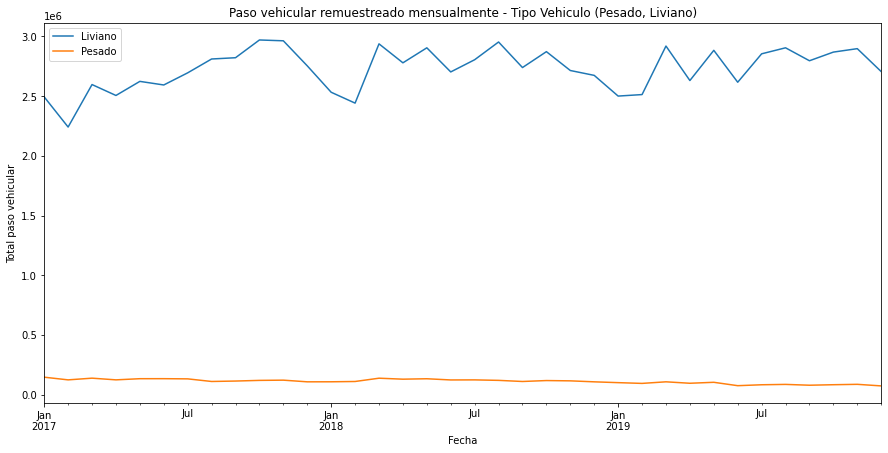

In [44]:
fig= plt.figure(figsize=(15,7))
illia[illia.tipo_vehiculo=='Liviano'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
illia[illia.tipo_vehiculo=='Pesado'].groupby(['mes_ano'])['cantidad_pasos'].sum().plot()
plt.title("Paso vehicular remuestreado mensualmente - Tipo Vehiculo (Pesado, Liviano)")
plt.ylabel("Total paso vehicular")
plt.xlabel("Fecha")
plt.legend(['Liviano','Pesado'])
plt.show()

De aquí podemos notar que a pesar que en el gráfico de barras en la seccion *Comparación de otras características entre todas las estaciones frente a Illia* mostraba que la característica tipo de vehiculo estaba balanceada, en este grafico al hacerlo por el conteo de vehiculos la cantidad de vehículos pesados que pasa por la estacion Illia no es significante.

### 2.2.3. Manejo de valores atípicos u *outliers*

In [45]:
# Estadísticas
illia.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
periodo,752552.0,2017.826235,0.756176,2017.0,2017.0,2018.0,2018.0,2019.0
cantidad_pasos,752552.0,135.825550,386.818215,1.0,2.0,6.0,27.0,5330.0
hora,752552.0,12.012598,6.643998,0.0,7.0,12.0,18.0,23.0
mes,752552.0,6.514007,3.437815,1.0,4.0,7.0,10.0,12.0


Análisis estadístico de las variables numéricas de Illia, muestra promedios de paso vehicular mayores a 100 por hora. Siendo esta variable la de mayor variabilidad, desviación estandar mayor a 380. Debido a esto es importante realizar un estudio de los valores atípicos.  

**Valores atípicos:**

En estadística un valor atípico (en inglés *outlier*) es una observación que es numéricamente distante del resto de los datos. Las estadísticas derivadas de los conjuntos de datos que incluyen valores atípicos serán frecuentemente engañosas.

Los valores atípicos son en ocasiones una cuestión subjetiva, y existen numerosos métodos para clasificarlos. El método más impartido académicamente por su sencillez y resultados es el test de Tukey, que matematicamente están representados por las siguientes ecuaciones:

`q < Q1 - 1.5 * IQR` o `q > Q3 + 1.5 * IQR`

Donde q es el valor atípico, Q1 es el primer cuartil (25% de los datos), Q3 es el tercer cuartil e IQR es el rango intercuartílico. 

Rango intercuartico: Es la diferencia entre el tercer y el primer cuartil de una distribución. Es una medida de la dispersión estadística. `IQR = Q3 - Q1`

In [46]:
# Test de Tukey - filtro por 1.5 rangos intercuartilícos
def test_tukey(df,var):
    
    quartile1 = df[var].quantile(0.25)
    quartile3 = df[var].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range    
    
    return up_limit, low_limit

In [47]:
up_limit, low_limit = test_tukey(illia,'cantidad_pasos')
print(f"Límite superior de cantidad de pasos Illia: {up_limit}")
print(f"Límite infeior de cantidad de pasos Illia: {low_limit}")

Límite superior de cantidad de pasos Illia: 64.5
Límite infeior de cantidad de pasos Illia: -35.5


Valores por encima de 64.5 en flujo vehicular diario se consideran valores atípicos, según el test de Tukey.

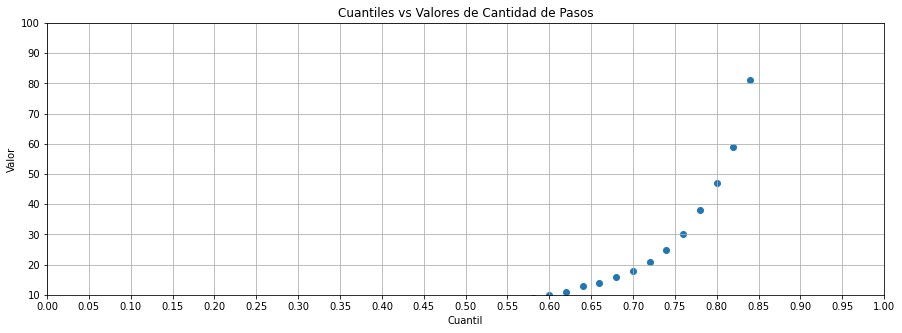

In [48]:
x= np.linspace(0,1,num=51)
y= illia.cantidad_pasos.quantile(x)

plt.figure(figsize=(15,5))
plt.scatter(x,y)
plt.xlim((0,0.99))
plt.ylim((10,100))
plt.ylabel('Valor')
plt.xlabel('Cuantil')
plt.title('Cuantiles vs Valores de Cantidad de Pasos')
plt.xticks(np.linspace(0,1,num=21))
plt.grid(True)
plt.show()

Analizando la gráfica de valor vs cuantiles podemos observar que alrededor del 84% de los datos están por debajo del límite encontrado por el test de Tukey y el incremento en los valores es exponencial.

In [49]:
# Regla de las tres desviaciones estandar

up_limit = illia['cantidad_pasos'].mean()+ 3*illia['cantidad_pasos'].std()
low_limit = illia['cantidad_pasos'].mean()- 3*illia['cantidad_pasos'].std()
print(f"Límite superior de cantidad de pasos Illia: {up_limit}")
print(f"Límite infeior de cantidad de pasos Illia: {low_limit}")

Límite superior de cantidad de pasos Illia: 1296.2801940042073
Límite infeior de cantidad de pasos Illia: -1024.6290948110618


In [50]:
tukey = (1-(illia[illia.cantidad_pasos<=64].shape[0]/illia.shape[0]))*100
print(f"Cantidad de datos filtrados segun test de Tukey: {round(tukey,2)}%")
tresD = (1-(illia[illia.cantidad_pasos<=1296].shape[0]/illia.shape[0]))*100
print(f"Cantidad de datos filtrados segun tres desviaciones estandar: {round(tresD,2)}%")

Cantidad de datos filtrados segun test de Tukey: 17.35%
Cantidad de datos filtrados segun tres desviaciones estandar: 3.26%


In [51]:
illia[illia.cantidad_pasos<=64].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
periodo,621968.0,2017.793800,0.741489,2017.0,2017.0,2018.0,2018.0,2019.0
cantidad_pasos,621968.0,9.404670,12.546317,1.0,2.0,4.0,11.0,64.0
hora,621968.0,11.968849,6.683290,0.0,7.0,12.0,18.0,23.0
mes,621968.0,6.502227,3.434862,1.0,4.0,7.0,9.0,12.0


In [52]:
illia[illia.cantidad_pasos<=1296].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
periodo,727992.0,2017.820190,0.752750,2017.0,2017.0,2018.0,2018.0,2019.0
cantidad_pasos,727992.0,80.609019,228.947293,1.0,2.0,6.0,22.0,1296.0
hora,727992.0,11.913836,6.696129,0.0,7.0,12.0,18.0,23.0
mes,727992.0,6.507852,3.440678,1.0,4.0,7.0,10.0,12.0


En caso de utilizar la remoción de valores atípicos enfocada a la variable cantidad de paso vehicular por hora, se encuentra que el test de Tukey removería 17% y por otro lado, el método de tres desviaciones estandar removería solo 3%. Adicionalmente, en caso de utilizar Tukey la desviación estandar de los datos pasaría de 383 a 12, lo cual es un ajuste bastante significativo. Mientras que al remover 3% de los datos con las tres desviaciones estandar cambia de 383 a 228. Una reducción de 155 en la desviación estandar al quitar el 3% de los datos mientras una reducción de 371 al quitar 17%. 

Por lo tanto, en caso de remover casi 1/5 de los datos, se reduce mucho la variabilidad pero se pierden una gran cantidad de datos. Mientras que al remover solamente un 3% de ellos se logra un impacto significativo en la reducción de la variabilidad sin perder una gran cantidad de datos, lastimosamente habría afectación por la variabilidad pero sería menor que utilizando los datos originales.  

* Por forma de pago

Al revisar los valores atípicos de Illia encontramos que la mayoría de registros corresponden a la forma de pago Telepase, 

In [53]:
# Forma de pago - Efectivo

up_limit, low_limit = test_tukey(illia[illia.forma_pago=='EFECTIVO'],'cantidad_pasos') # Test de Tukey 
print(f"Límite superior de cantidad de pasos Illia: {up_limit}")
print(f"Límite infeior de cantidad de pasos Illia: {low_limit}")

Límite superior de cantidad de pasos Illia: 257.0
Límite infeior de cantidad de pasos Illia: -151.0


In [54]:
# Forma de pago - Telepase

up_limit, low_limit = test_tukey(illia[illia.forma_pago=='TELEPASE'],'cantidad_pasos') # Test de Tukey 
print(f"Límite superior de cantidad de pasos Illia: {up_limit}")
print(f"Límite infeior de cantidad de pasos Illia: {low_limit}")

Límite superior de cantidad de pasos Illia: 214.5
Límite infeior de cantidad de pasos Illia: -125.5


Según las 2 formas de pagos más recurrentes, los valores atípicos se encuentran luego de distintos rangos, siendo un poco mayor para Efectivo:257 que para Telepase:214.

<a href="#0"><font size="1">Volver a contenidos</font></a>

### 2.3. Tendencia, Estacionalidad y Ruido<a id="explore3"></a>

Para efectos de este proyecto se utilizará el siguiente filtro, que involucra las características más comunes en los datos:

In [55]:
illia_preprocess = illia[(illia.tipo_vehiculo=='Liviano') & ((illia.forma_pago=='EFECTIVO') | (illia.forma_pago=='TELEPASE'))]

In [56]:
# Agrupación por fecha
dataset_illia = illia_preprocess.groupby(["fecha"])["cantidad_pasos"].sum().reset_index()

In [57]:
# Indexar las fechas
dataset_illia.set_index("fecha",inplace=True)

In [58]:
# Resamplear en semanas y en días
dataset_illia_dia = dataset_illia.resample("D").sum()
dataset_illia_sem = dataset_illia.resample("W").sum()

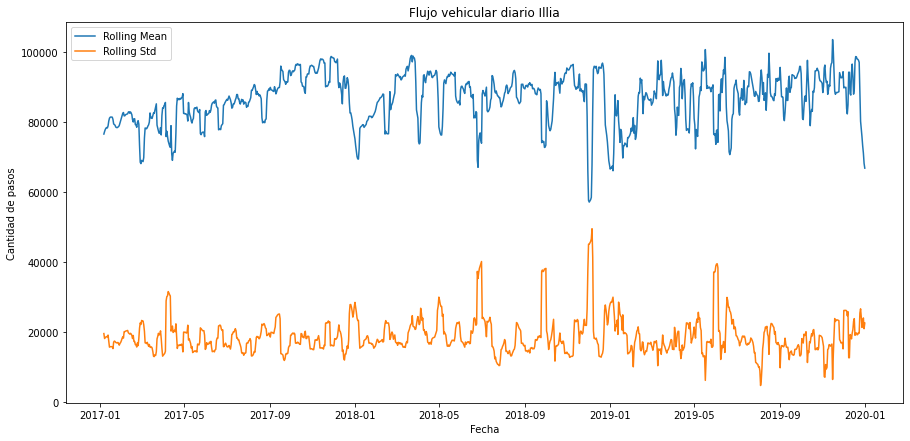

In [59]:
plt.figure(figsize=(15, 7))
ventana = 7 # Número de observaciones utilizadas para calcular las estadísticas.
            # Cada ventana tendrá un valor fijo.
plt.plot(dataset_illia_dia.cantidad_pasos.rolling(window=ventana,center=False).mean(),label='Rolling Mean');
plt.plot(dataset_illia_dia.cantidad_pasos.rolling(window=ventana,center=False).std(),label='Rolling Std');
plt.title('Flujo vehicular diario Illia')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de pasos')
plt.legend()
plt.show()

Se puede ver un crecimiento abrupto de la desviación estandar a finales del 2018 y una disminución del promedio de la cantidad de pasos, lo que indicaría una falla en el sistema de registro o de conteo de flujo vehicular durante esa semana.

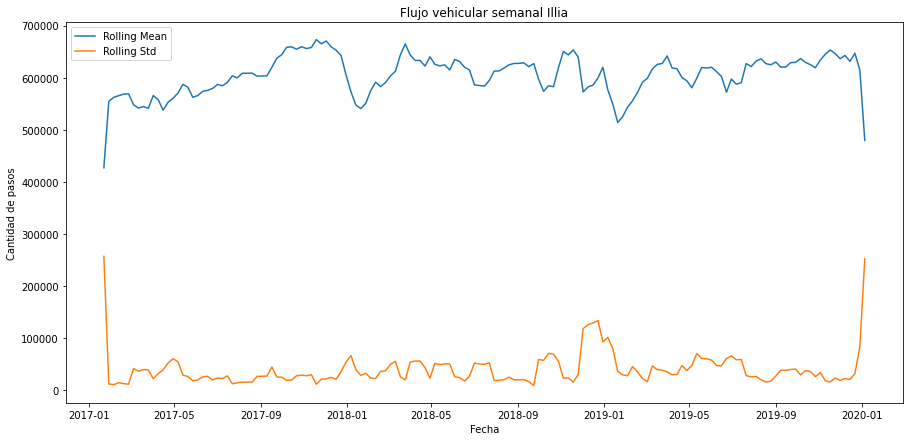

In [60]:
plt.figure(figsize=(15, 7))
plt.plot(dataset_illia_sem.cantidad_pasos.rolling(window=4,center=False).mean(),label='Rolling Mean');
plt.plot(dataset_illia_sem.cantidad_pasos.rolling(window=4,center=False).std(),label='Rolling Std');
plt.title('Flujo vehicular semanal Illia')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de pasos')
plt.legend()
plt.show()

La gráfica anterior vista por semanas nos muestra el mismo comportamiento descrito anteriormente y se observa una estacionalidad en los promedios de la cantidad de pasos.

In [61]:
from pylab import rcParams
import statsmodels.api as sm

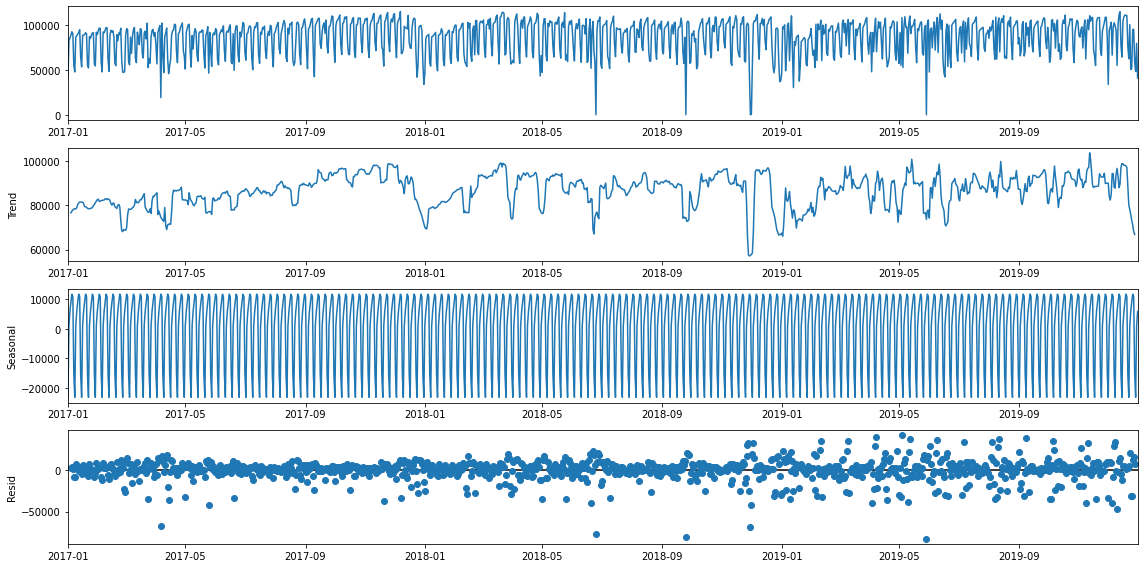

In [62]:
rcParams['figure.figsize'] = 16, 8 
des = sm.tsa.seasonal_decompose(dataset_illia_dia, model='additive', period=7)
fig = des.plot() 
plt.show()

Para los datos diarios se observa:

A nivel de residuos se puede ver que a partir del 2019 los residuos son más caóticos comparandolos con años anteriores. Y se corrobora en la gráfica de tendencia el incremento paulatino de crecimiento desde enero a diciembre de cada año, con altos y bajos alrededor de cada 15 días. 

Está tendencia se ve afectada  luego del 2019, ya que la variabilidad de los datos se incrementa como lo indican los residuales. 

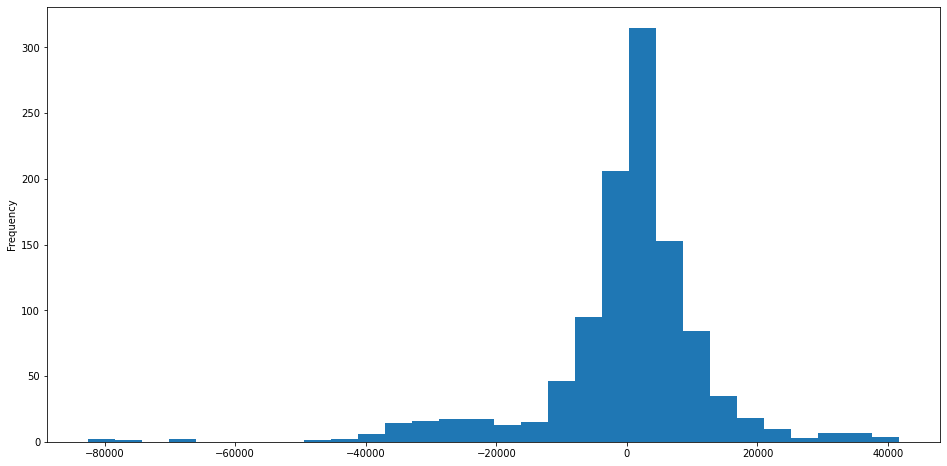

In [63]:
des.resid.plot(kind="hist", bins=30)
plt.show()

Como se mencionó anteriormente, los residuales están bastante cercanos a cero, exceptuando el periodo luego del 2019. Es decir, en este histograma la mayoría de datos esparcidos corresponde a fechas posteriores al 2019-01-01.

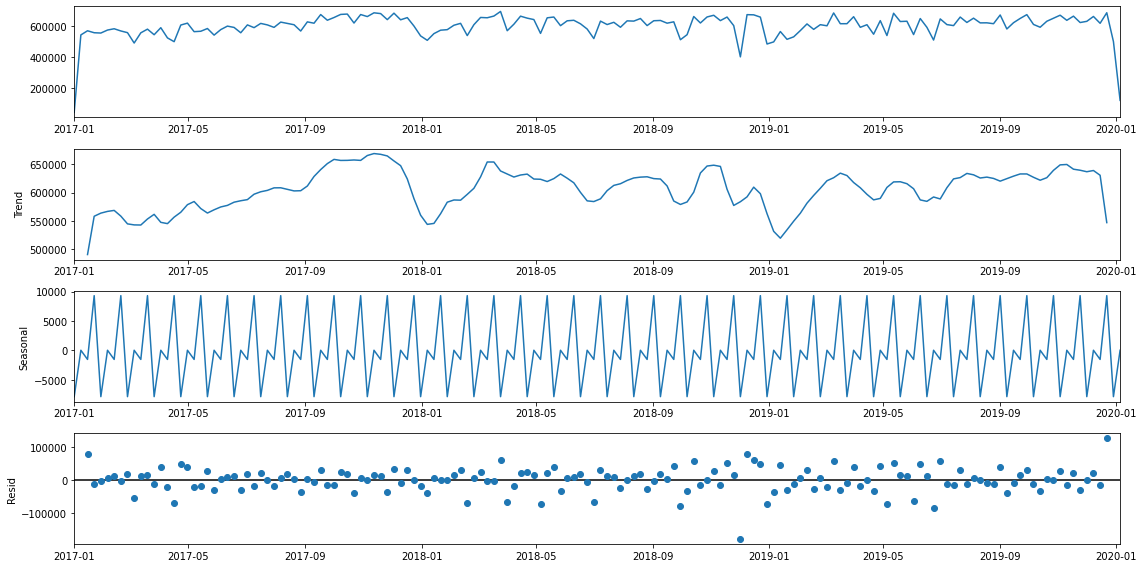

In [64]:
des2 = sm.tsa.seasonal_decompose(dataset_illia_sem, model='additive', period=4)
fig = des2.plot() 
plt.show()

Analizando en periodos de cuatro semanas se identifica rápidamente una gran variabilidad en el valor de los residuales a lo largo de todo el período analizado. Adicionalmente, la tendencia de incremento de enero a diciembre para cada año no es tán clara en esta gráfica. 

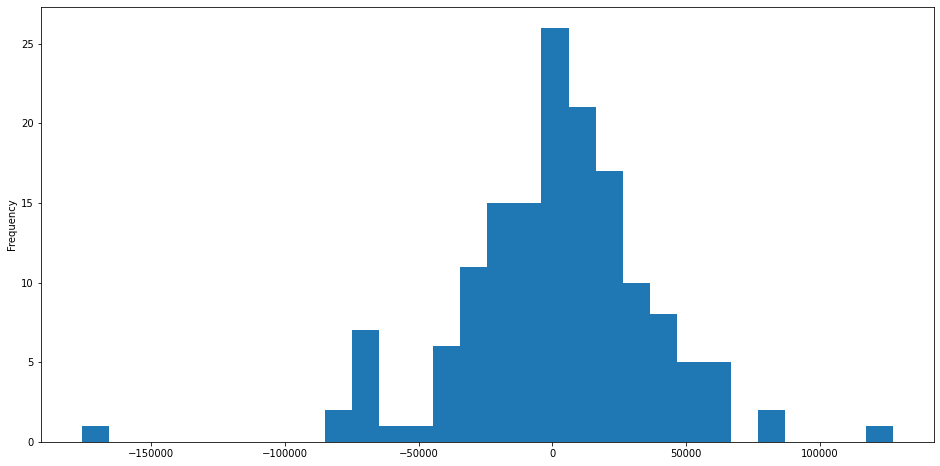

In [65]:
des2.resid.plot(kind="hist", bins=30)
plt.show()

El histograma de residuales es mucho más grande en valores distintos a cero. Debido al cmabio en agregación realizado.

* **Test para confirmar estacionalidad, utilizando hipótesis nula:**

Una prueba de Dickey-Fuller aumentada (ADF) es una prueba de raíz unitaria para una muestra de una serie de tiempo. Es una versión aumentada de la prueba Dickey-Fuller para un conjunto más amplio y más complejo de modelos de series de tiempo. La estadística Dickey-Fuller Aumentada (ADF), utilizada en la prueba, es un número negativo. Cuanto más negativo es, más fuerte es el rechazo de la hipótesis nula de que existe una raíz unitaria para un cierto nivel de confianza.

In [66]:
from statsmodels.tsa.stattools import adfuller # test para confirmar estacionalidad
def test_stationarity(timeseries, ventana):
    #Determing rolling statistics
    rolmean = timeseries.rolling(window=ventana).mean()
    rolstd = timeseries.rolling(window=ventana).std()
    #Plot rolling statistics:
    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    print("P-Value:", dftest[1])
    
    p = dftest[1]
    if p <= 0.05:
        print(f" La serie es Estacionaria")
    else:
        print(f" La serie es No-Estacionaria")

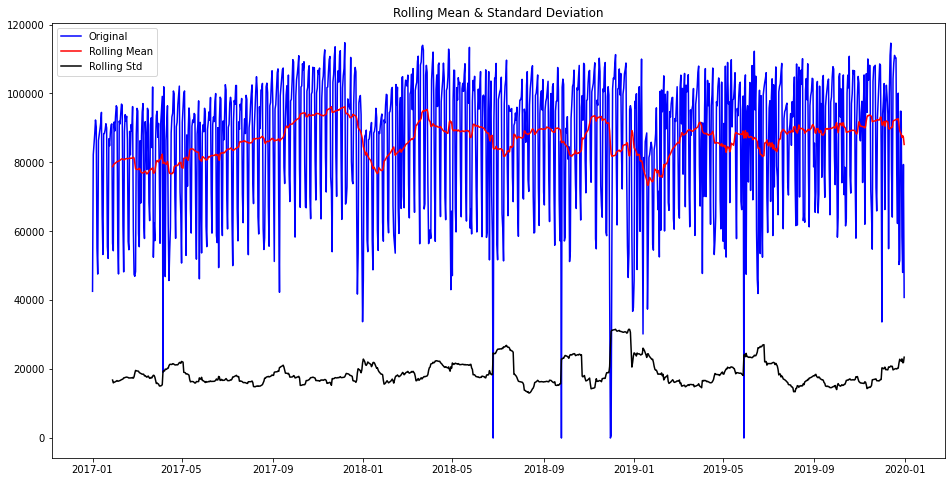

Results of Dickey-Fuller Test:
P-Value: 4.204517138007265e-05
 La serie es Estacionaria


In [67]:
test_stationarity(dataset_illia_dia, 28)

Dickey-Fuller Aumentada (ADF) para valores diarios nos confirma de acuerdo al p-value que se rechaza la hipótesis nula y la serie es estacionaria.

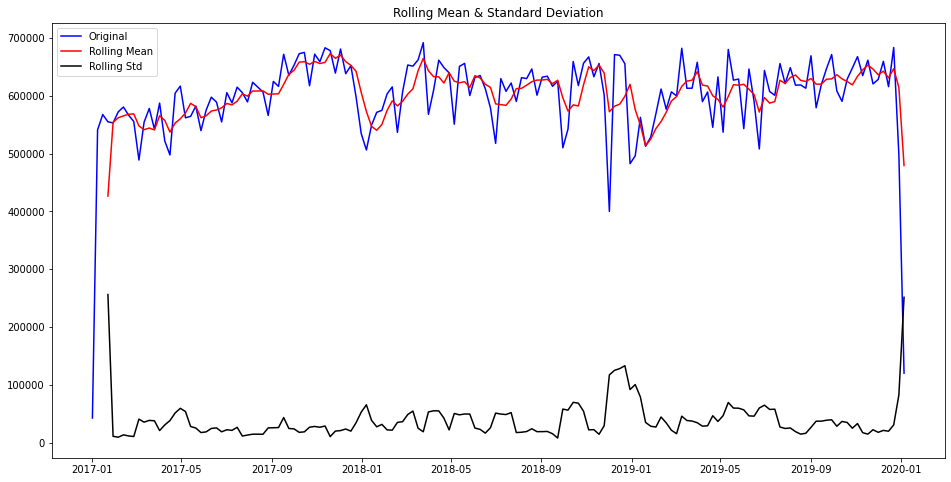

Results of Dickey-Fuller Test:
P-Value: 7.345491066360189e-17
 La serie es Estacionaria


In [68]:
test_stationarity(dataset_illia_sem, 4)

Dickey-Fuller Aumentada (ADF) para valores semanales nos confirma de acuerdo al p-value que se rechaza la hipótesis nula y la serie es estacionaria.

Esto implica que tanto los datos diarios como los semanales se pueden utilizar en modelos autorregresivos integrado de promedio móvil o ARIMA.

<a href="#0"><font size="1">Volver a contenidos</font></a>

### 2.4. Autocorrelación y Autocorrelación parcial<a id="explore4"></a>

In [69]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

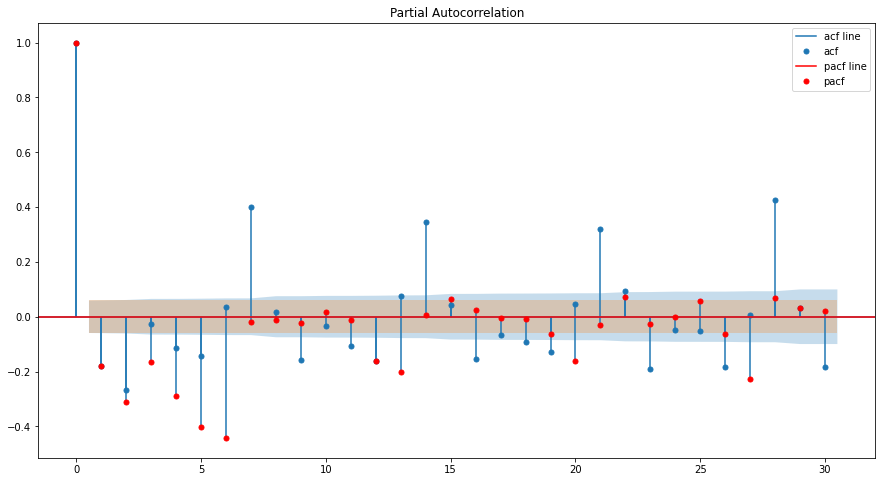

In [70]:
fig=plt.figure(figsize=(15,8))
ax1= fig.add_subplot(111)
fig=plot_acf(dataset_illia_dia['cantidad_pasos'].diff().dropna(), lags=30, alpha= 0.05, ax=ax1)
#ax2= fig.add_subplot(122)
fig=plot_pacf(dataset_illia_dia['cantidad_pasos'].diff().dropna(), lags=30, alpha= 0.05, ax=ax1, color="r")
plt.legend(["acf line", "acf", "pacf line", "pacf"])
plt.show()

El diagrama anterior muestra la autocorrelación y autocorrelación parcial, que me muestra que tanto se relaciona mi dato con datos del futuro. Ya que estamos usando una **diferencia** de 1 día compara con el día posterior y se observa que cada 7 puntos 
la correlación vuelve al cero. Debido a esto la próxima gráfica tiene una diferencia de 7. 

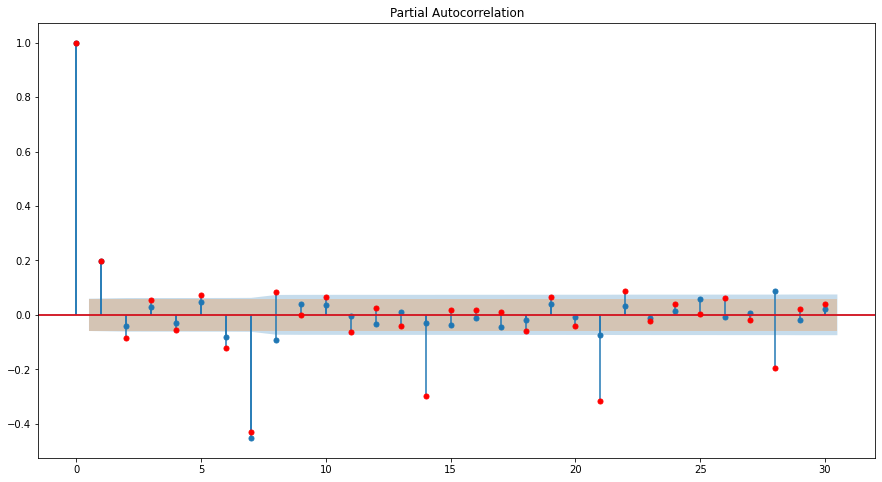

In [71]:
fig=plt.figure(figsize=(15,8))
ax1= fig.add_subplot(111)
fig=plot_acf(dataset_illia_dia['cantidad_pasos'].diff(7).dropna(), lags=30, alpha= 0.05, ax=ax1)
#ax2= fig.add_subplot(122)
fig=plot_pacf(dataset_illia_dia['cantidad_pasos'].diff(7).dropna(), lags=30, alpha= 0.05, ax=ax1, color="r")
plt.show()

Observando el diagrama anterior, el dataset remuestreado por día con seasonality 28 tiene los siguientes valores de p,d y q.

* (P,D,Q) = (1,1,4) ó (2,1,4) S=28

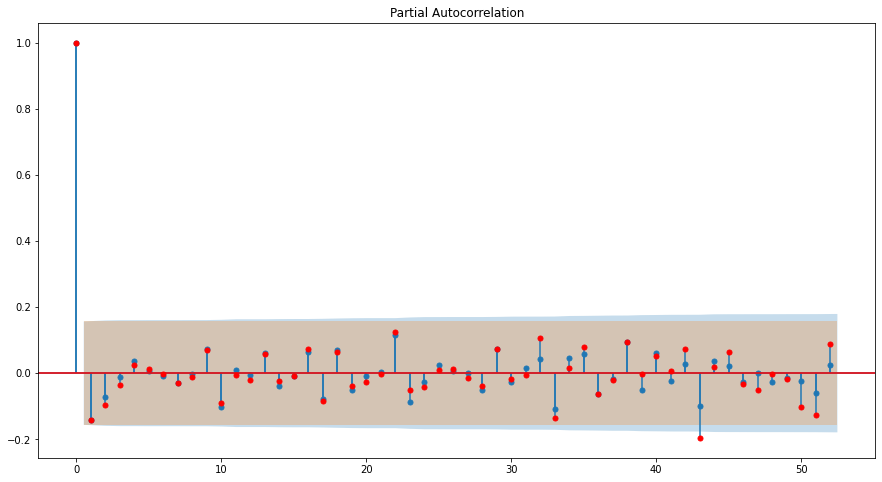

In [72]:
fig=plt.figure(figsize=(15,8))
ax1= fig.add_subplot(111)
fig=plot_acf(dataset_illia_sem['cantidad_pasos'].diff().dropna(), lags=52, alpha= 0.05, ax=ax1)
#ax2= fig.add_subplot(122)
fig=plot_pacf(dataset_illia_sem['cantidad_pasos'].diff().dropna(), lags=52, alpha= 0.05,ax=ax1, color="r")
plt.show()

Dataset remuestreado por semana con lag 1.

* (p,d,q) = (1,0,0) ó (0,0,1)

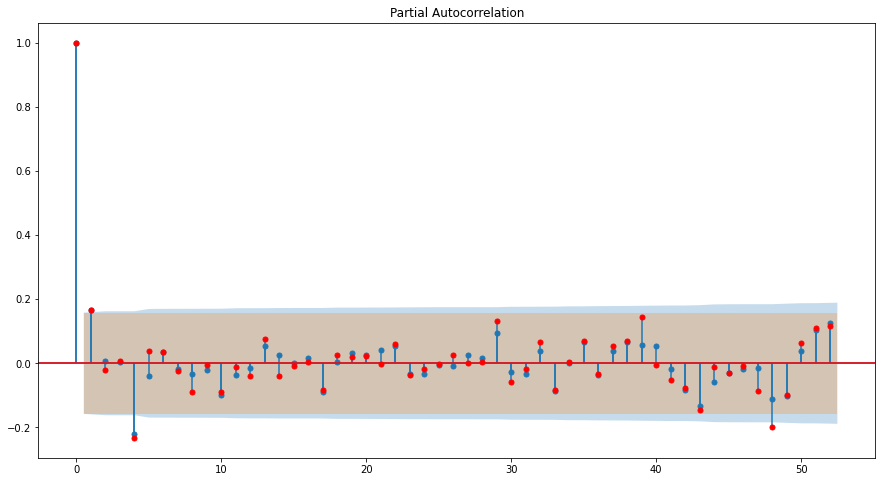

In [73]:
fig=plt.figure(figsize=(15,8))
ax1= fig.add_subplot(111)
fig=plot_acf(dataset_illia_sem['cantidad_pasos'].diff(4).dropna(), lags=52, alpha= 0.05, ax=ax1)
#ax2= fig.add_subplot(122)
fig=plot_pacf(dataset_illia_sem['cantidad_pasos'].diff(4).dropna(), lags=52, alpha= 0.05, ax=ax1, color="r")
plt.show()

Dataset remuestreado por semana con lag 4.
* (p,d,q) = (1,1,2) ó (1,1,3)

<a href="#0"><font size="1">Volver a contenidos</font></a>

## 3. Modelos<a id="modeling"></a>

### 3.1. Modelo Benchmark<a id="modeling1"></a>

El modelo benchmark que se utiliza es una regresión lineal de los datos

In [74]:
from sklearn.linear_model import LinearRegression

In [75]:
dataset_illia_dia['fecha_numero'] = dataset_illia_dia.index.map(datetime.datetime.toordinal)
dataset_illia_sem['fecha_numero'] = dataset_illia_sem.index.map(datetime.datetime.toordinal)

In [76]:
Xd_train = dataset_illia_dia['fecha_numero'].loc['2017-01-01':'2019-09-30']
Xd_test = dataset_illia_dia['fecha_numero'].loc['2019-10-01':]
yd_train = dataset_illia_dia['cantidad_pasos'].loc['2017-01-01':'2019-09-30']
yd_test = dataset_illia_dia['cantidad_pasos'].loc['2019-10-01':]

In [77]:
Xs_train = dataset_illia_sem['fecha_numero'].loc['2017-01-01':'2019-09-30']
Xs_test = dataset_illia_sem['fecha_numero'].loc['2019-10-01':]
ys_train = dataset_illia_sem['cantidad_pasos'].loc['2017-01-01':'2019-09-30']
ys_test = dataset_illia_sem['cantidad_pasos'].loc['2019-10-01':]

In [78]:
lrd = LinearRegression().fit(Xd_train.values.reshape(-1, 1), yd_train)
lrs = LinearRegression().fit(Xs_train.values.reshape(-1, 1), ys_train)

In [79]:
yd_pred_train = lrd.predict(Xd_train.values.reshape(-1, 1))
yd_pred_test = lrd.predict(Xd_test.values.reshape(-1, 1))

ys_pred_train = lrs.predict(Xs_train.values.reshape(-1, 1))
ys_pred_test = lrs.predict(Xs_test.values.reshape(-1, 1))

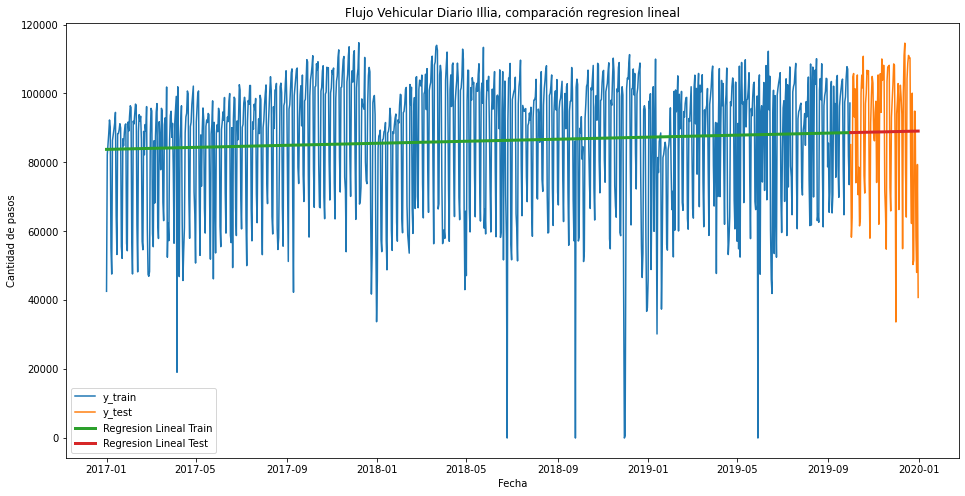

In [80]:
plt.plot(Xd_train.index, yd_train, label = 'y_train')
plt.plot(Xd_test.index, yd_test, label = 'y_test')
#plt.plot(dataset_Illia_W.cantidad_peajes, label='Serie suavizada')
plt.plot(Xd_train.index, yd_pred_train, lw = 3, label = 'Regresion Lineal Train')
plt.plot(Xd_test.index, yd_pred_test, lw = 3, label = 'Regresion Lineal Test')
plt.title('Flujo Vehicular Diario Illia, comparación regresion lineal')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de pasos')
plt.legend()
plt.show()

Como se puede observar en la gráfica la línea recta representa los valores promedio pero no se acopla a la tendencia ni a la estacionaridad de los valores diarios. 

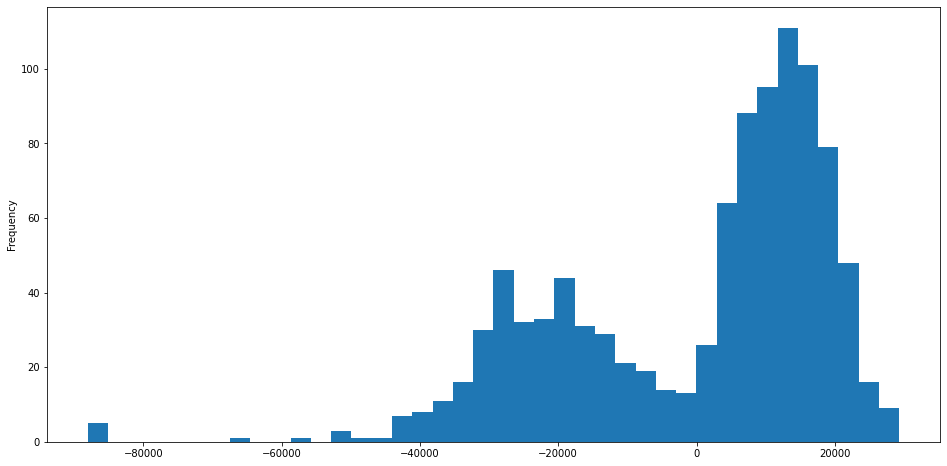

In [81]:
(yd_train - yd_pred_train).plot(kind='hist', bins=40)
plt.show()

La anterior gráfica muestra la distribución de errores, si la distribución fuera normal con la mayoría de datos en 0 indicaría que el modelo predice satisfactoriamente, aquí observamos que hay predicciones principalmente desfasadas ya sea por arriba o por debajo del valor esperado con diferencias entre -60000 a 35000. 

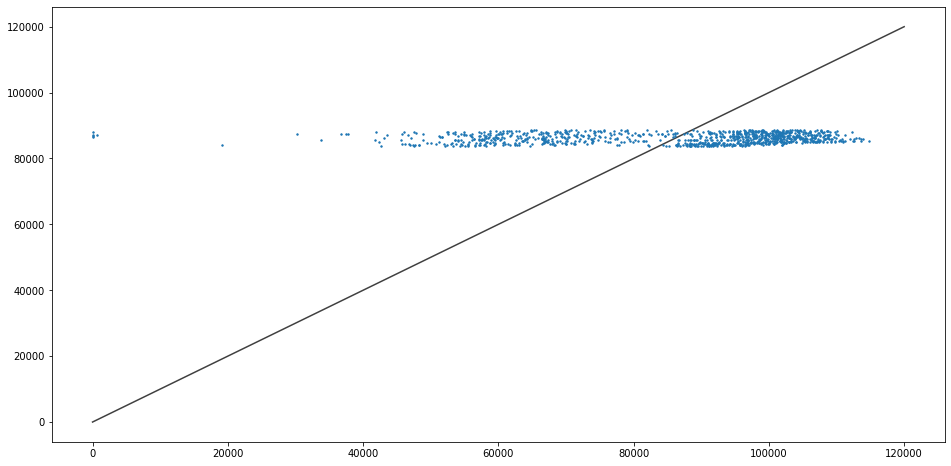

In [82]:
plt.scatter(yd_train, yd_pred_train, s=2)
plt.plot([0, 120000], [0, 120000], 'k-', alpha=0.75, zorder=0)
plt.show()

Adicionalmente en la anterior gráfica podemos observar que los valores a predecir estan esparcidos y la línea recta no se ajusta bien a los valores. 

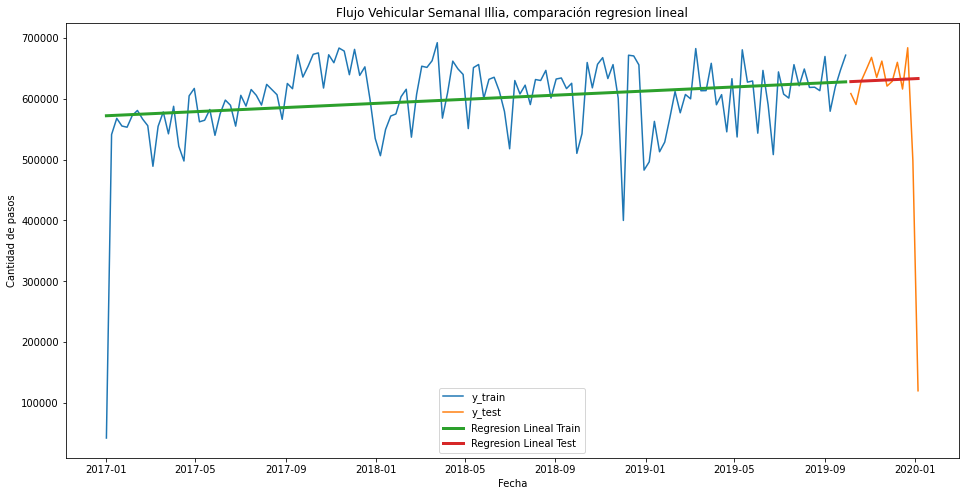

In [83]:
plt.plot(Xs_train.index, ys_train, label = 'y_train')
plt.plot(Xs_test.index, ys_test, label = 'y_test')
#plt.plot(dataset_Illia_W.cantidad_peajes, label='Serie suavizada')
plt.plot(Xs_train.index, ys_pred_train, lw = 3, label = 'Regresion Lineal Train')
plt.plot(Xs_test.index, ys_pred_test, lw = 3, label = 'Regresion Lineal Test')
plt.title('Flujo Vehicular Semanal Illia, comparación regresion lineal')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de pasos')
plt.legend()
plt.show()

Comparando con los valores semanales, se observa una tendencia similar, en dónde no se ajusta bien la línea recta pero es algo menor la diferencia.

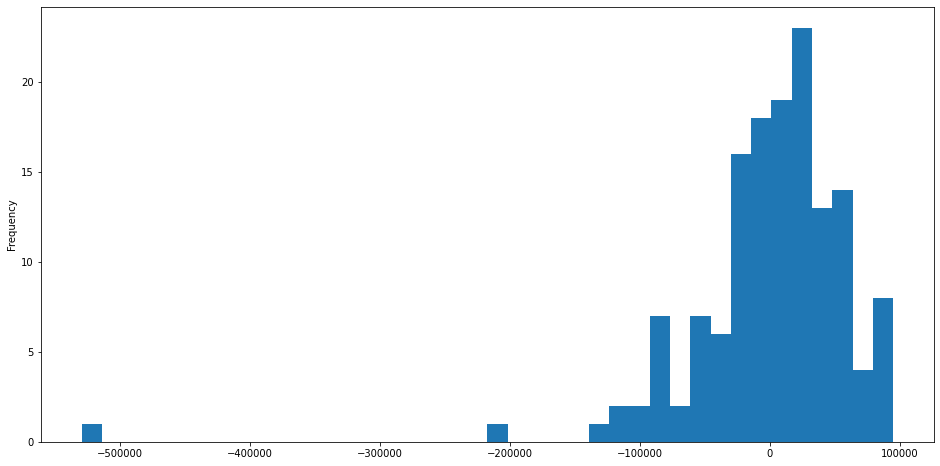

In [84]:
(ys_train - ys_pred_train).plot(kind='hist', bins=40)
plt.show()

En el histograma que muestra que tan alejados son los valores al valor objetivo, para los datos semanales, ya la mayoría de datos están más cercanos a cero y la variación se da entre -15000 y 10000.

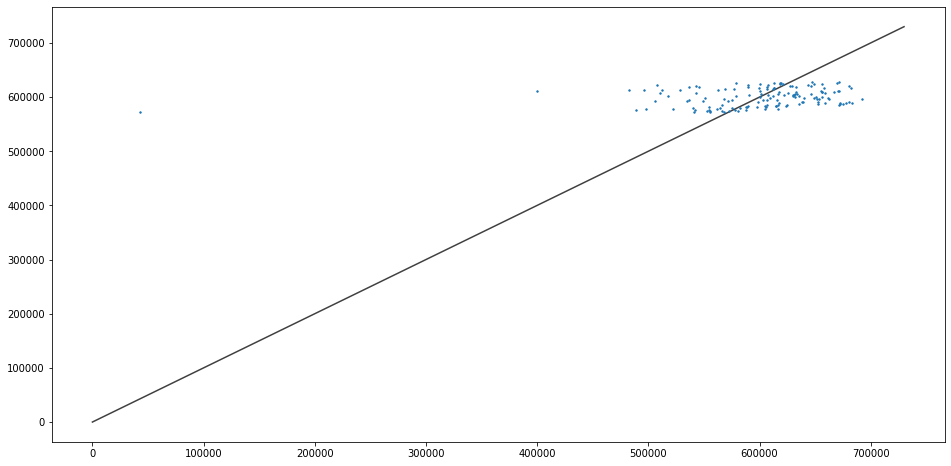

In [85]:
plt.scatter(ys_train, ys_pred_train, s=2)
plt.plot([0, 730000], [0, 730000], 'k-', alpha=0.75, zorder=0)
plt.show()

Y en esta última gráfica como se esperaba, la dispersión se redujo un poco. Ya que la estacionalidad y la similitud entre las semanas reduce la variación alta de los valores diarios.

In [86]:
from sklearn.metrics import mean_squared_error

A pesar de que gráficamente se pueden comparar las dos transformaciones de datos, es necesario calcular el error medio cuadrado.  

In [87]:
rmse_dia = mean_squared_error(yd_train, yd_pred_train, squared=False)
rmse_sem = mean_squared_error(ys_train, ys_pred_train, squared=False)

In [88]:
print("RMSE tomando datos remuestreados por Dia:", round(rmse_dia, 2))
print("RMSE tomando datos remuestreados por Semana:", round(rmse_sem, 2))

RMSE tomando datos remuestreados por Dia: 19421.97
RMSE tomando datos remuestreados por Semana: 66974.53


Sorprendentemente el modelo se desempeña mejor para los valores diarios y peor en los semanales. En general una diferencia cercana a 20 mil con respecto valor objetivo es demasiado grande, teniendo en cuenta una variación de los datos en un rango de 200 mil.

<a href="#0"><font size="1">Volver a contenidos</font></a>

### 3.2. Modelo ARIMA<a id="modeling2"></a>

Modelo autorregresivo integrado de promedio móvil o ARIMA (acrónimo del inglés autoregressive integrated moving average) es un modelo estadístico que utiliza variaciones y regresiones de datos estadísticos con el fin de encontrar patrones para una predicción hacia el futuro.

El modelo ARIMA necesita identificar los coeficientes y número de regresiones que se utilizarán. Este modelo es muy sensible a la precisión con que se determinen sus coeficientes.

Se suele expresar como ARIMA(p,d,q) donde los parámetros p, d y q son números enteros no negativos que indican el orden de las distintas componentes del modelo — respectivamente, las componentes autorregresiva, integrada y de media móvil. Cuando alguno de los tres parámetros es cero, es común omitir las letras correspondientes del acrónimo — AR para la componente autorregresiva, I para la integrada y MA para la media móvil. Por ejemplo, ARIMA(0,1,0) se puede expresar como I(1) y ARIMA(0,0,1) como MA(1).

El modelo ARIMA puede generalizarse aún más para considerar el efecto de la estacionalidad. En ese caso, se habla de un modelo SARIMA (seasonal autoregressive integrated moving average).

In [89]:
from statsmodels.tsa.arima.model import ARIMA

In [90]:
model_dia = ARIMA(yd_train, order=(0, 1, 1), seasonal_order=(1, 1, 3, 28), enforce_stationarity=False,
    enforce_invertibility=False)

In [91]:
result_dia = model_dia.fit() # entrenar el modelo

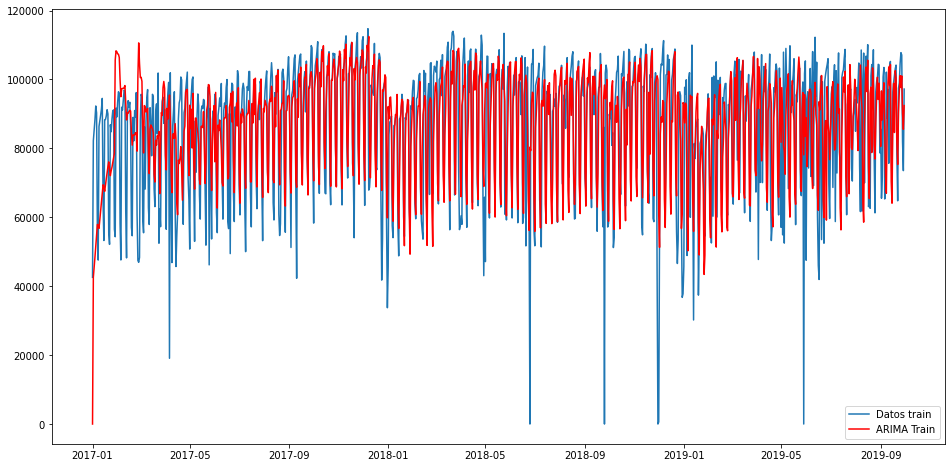

In [92]:
plt.plot(yd_train)
plt.plot(result_dia.fittedvalues, color='red')

plt.legend(["Datos train", "ARIMA Train"])
#plt.xlim(pd.to_datetime("1st of jan, 2017"), pd.to_datetime("31st of jan, 2017"))

Al inicio de la gráfica se puede observar como el modelo se va entrenando con los datos y se va adaptando a la tendencia de los datos reales.

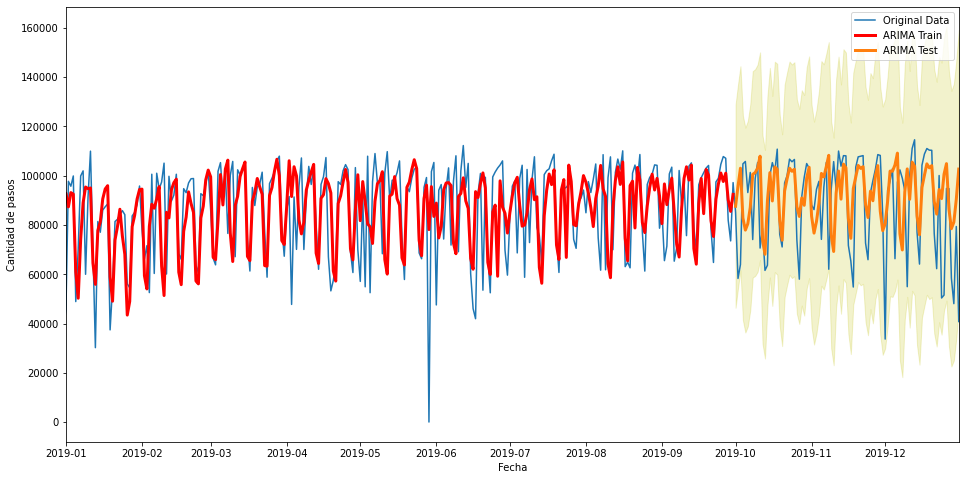

In [93]:
yd_train_pred = result_dia.predict('2017-01-01', '2019-09-30')
yd_test_pred = result_dia.predict('2019-10-01', '2019-12-31')
intervalo = result_dia.get_forecast("2019-12-31").conf_int()

plt.plot(dataset_illia_dia.drop(["fecha_numero"], axis=1), label="Original Data")
plt.plot(Xd_train.index, yd_train_pred, lw = 3, label = 'ARIMA Train', color="r")
plt.plot(Xd_test.index, yd_test_pred, lw = 3, label = 'ARIMA Test')
plt.fill_between(intervalo.index,
                intervalo.iloc[:, 0],
                intervalo.iloc[:, 1], color='y', alpha=.2)


plt.xlabel('Fecha')
plt.ylabel('Cantidad de pasos')
plt.legend()

plt.xlim(pd.to_datetime("1st of jan, 2019"), pd.to_datetime("31st of dec, 2019"))
plt.show()

Luego de modificar los hyperparametros del modelo, la gráfica resultante que se muestra arriba de esta celda nos muestra como el modelo se comporta y predice los datos. En general se ve un mejor comportamiento que el modelo benchmark pero en los últimos días no se acopla muy bien al decenso presente en los datos reales. 

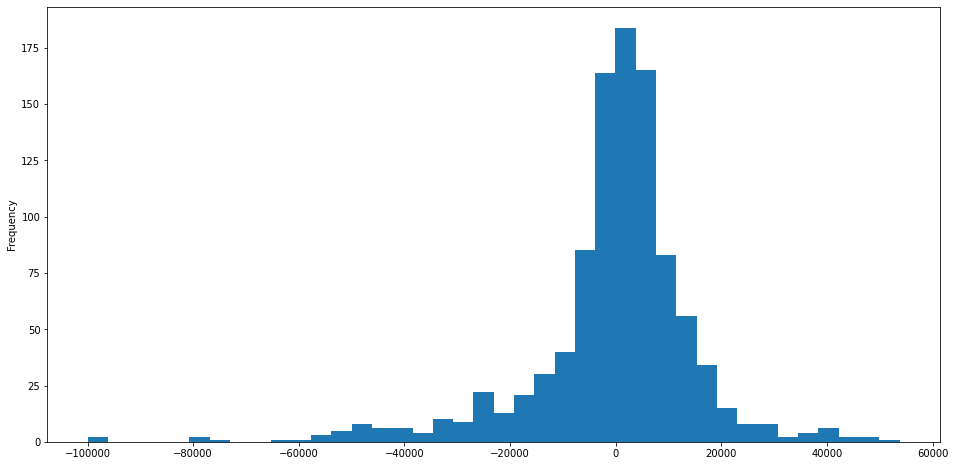

In [94]:
result_dia.resid.plot(kind="hist", bins=40)
plt.show()

Los residuales están mucho mejor distribuidos que antes pero el rango entre los residuales sigue siendo bastante grande.

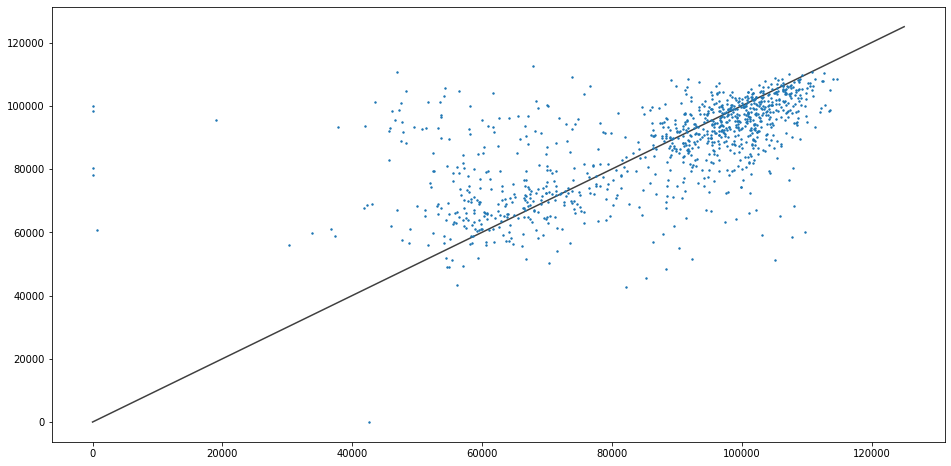

In [95]:
plt.scatter(yd_train, yd_train_pred, s=2)
plt.plot([0, 125000], [0, 125000], 'k-', alpha=0.75, zorder=0)
plt.show()

Para el modelo ARIMA se puede observar una mejor correlación de los datos hacia el modelo, un mejor ajuste.

In [96]:
rmse_dia = mean_squared_error(yd_train, yd_train_pred, squared=False)
print("RMSE Modelo ARIMA tomando datos remuestreados por Dia:", round(rmse_dia, 2))

RMSE Modelo ARIMA tomando datos remuestreados por Dia: 15789.88


Al calcular el error se nota una mejora significativa, una reducción en 4 mil para el error, pero sigue siendo bastante alto.

In [97]:
result_dia.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                         
================================================================================================
Dep. Variable:                           cantidad_pasos   No. Observations:                 1003
Model:             ARIMA(0, 1, 1)x(1, 1, [1, 2, 3], 28)   Log Likelihood               -9873.467
Date:                                  Sun, 12 Sep 2021   AIC                          19758.934
Time:                                          23:04:01   BIC                          19787.668
Sample:                                      01-01-2017   HQIC                         19769.918
                                           - 09-30-2019                                         
Covariance Type:                                    opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9318      0.023    -40.676      0.000      -0.977      -0.887
ar.S.L28       0.0526      0.733      0.072      0.943      -1.384       1.489
ma.S.L28      -0.8868      0.730     -1.214      0.225      -2.318       0.545
ma.S.L56       0.1260      0.602      0.209      0.834      -1.053       1.306
ma.S.L84      -0.0568      0.063     -0.900      0.368      -0.181       0.067
sigma2      4.421e+08   1.37e-08   3.23e+16      0.000    4.42e+08    4.42e+08
===================================================================================
Ljung-Box (L1) (Q):                  25.51   Jarque-Bera (JB):              2968.06
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.70   Skew:                            -1.77
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.11e+32. Standard errors may be unstable.
"""

**Teoría:** Criterio de información de Akaike

Es una medida de la calidad relativa de un modelo estadístico, para un conjunto dado de datos. Como tal, el AIC proporciona un medio para la selección del modelo.

AIC maneja un trade-off entre la bondad de ajuste del modelo y la complejidad del modelo. Se basa en la entropía de información: se ofrece una estimación relativa de la información perdida cuando se utiliza un modelo determinado para representar el proceso que genera los datos.

Un AIC de 19758 será nuestro valor a tratar de disminuir, entre más se disminuya quiere decir que el modelo se desempeña mejor.

In [98]:
model_sem = ARIMA(ys_train, order=(0, 1, 0), seasonal_order=(1, 1, 2, 4), enforce_stationarity=False,
    enforce_invertibility=False)

In [99]:
result_sem = model_sem.fit() # Segundo modelo ARIMA

Se ajusta un segundo modelo ARIMA modificando los valores de orden de temporada.

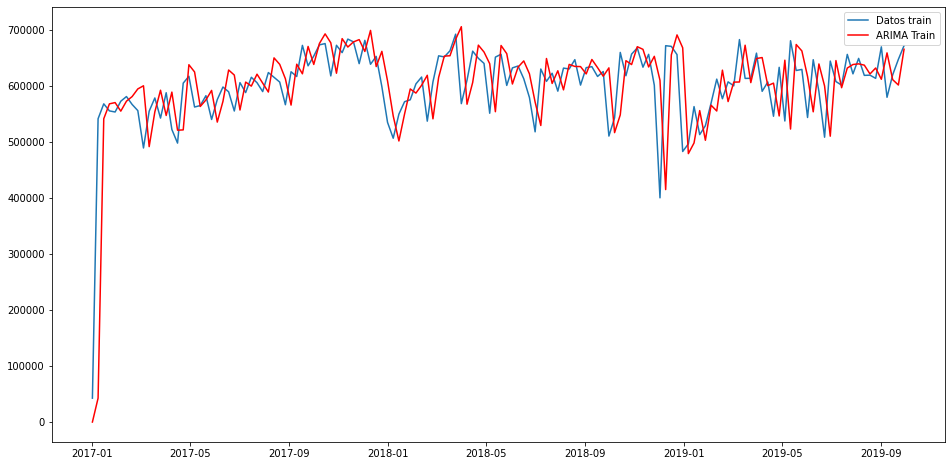

In [100]:
plt.plot(ys_train)
plt.plot(result_sem.fittedvalues, color='red')

plt.legend(["Datos train", "ARIMA Train"])
#plt.xlim(pd.to_datetime("1st of jan, 2017"), pd.to_datetime("31st of jan, 2017"))
plt.show()

Se observa que el modelo modificado se desempeña mucho mejor se ajusta muy cerca a los valores, con un pequeño lag, es decir modificando la fecha se ajustaría sobre la línea azul de los datos.

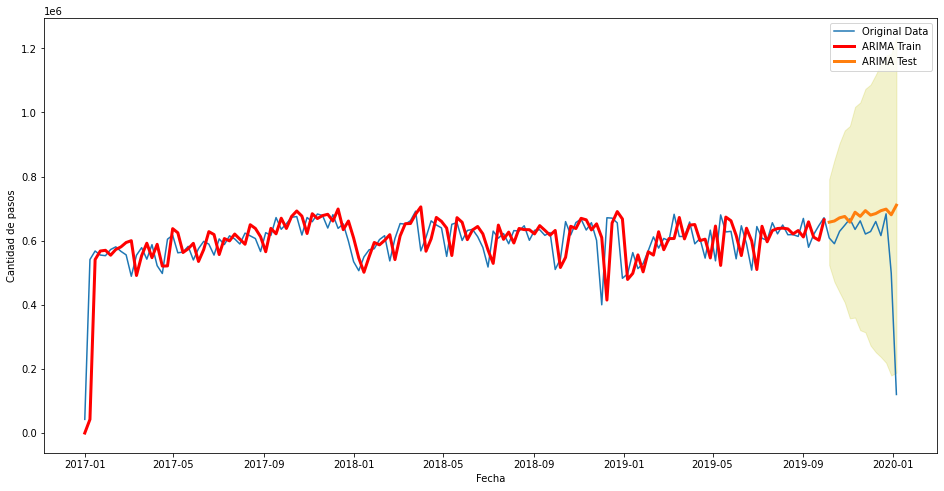

In [101]:
ys_train_pred = result_sem.predict('2017-01-01', '2019-09-30')[:-1]
ys_test_pred = result_sem.predict('2019-10-01', '2019-12-31')
intervalo = result_sem.get_forecast("2019-12-31").conf_int()

plt.plot(dataset_illia_sem.drop(["fecha_numero"], axis=1), label="Original Data")
plt.plot(Xs_train.index, ys_train_pred, lw = 3, label = 'ARIMA Train', color="r")
plt.plot(Xs_test.index, ys_test_pred, lw = 3, label = 'ARIMA Test')
plt.fill_between(intervalo.index,
                intervalo.iloc[:, 0],
                intervalo.iloc[:, 1], color='y', alpha=.2)

plt.xlabel('Fecha')
plt.ylabel('Cantidad de pasos')
plt.legend()

#plt.xlim(pd.to_datetime("1st of sep, 2019"), pd.to_datetime("31st of dec, 2019"))
plt.show()

Se nota que el modelo esta un poco encima de los valores reales y no cambia mucho en temporadas, lo que hace que no se ajuste tan bien.

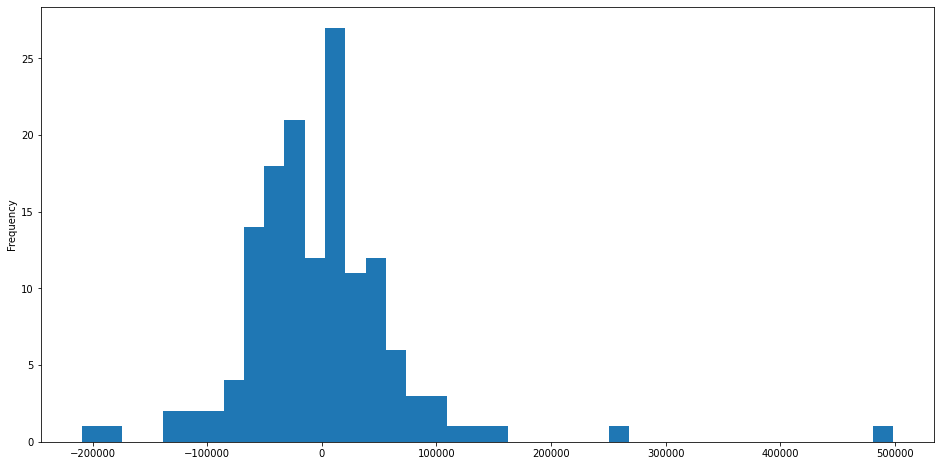

In [102]:
result_sem.resid.plot(kind="hist", bins=40)
plt.show()

Por su parte los residuales mejoraron un poco, la distribución es más empinada, es decir más datos se están acercando al 0, es decir al valor real.

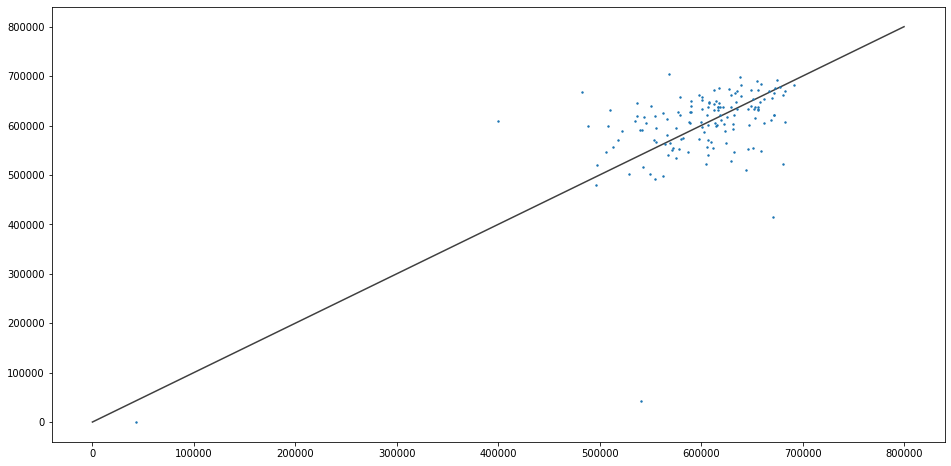

In [103]:
plt.scatter(ys_train, ys_train_pred, s=2)
plt.plot([0, 800000], [0, 800000], 'k-', alpha=0.75, zorder=0)
plt.show()

La correlación mostrada en la gráfica es un poco mejor. Modificar los valores de entrenamiento ayudaron en gran medida. Pero los datos por semana siguen siendo el amyor error.

In [104]:
rmse_sem = mean_squared_error(ys_train, ys_train_pred, squared=False)

print("RMSE Modelo ARIMA tomando datos remuestreados por Semana:", round(rmse_sem, 2))

RMSE Modelo ARIMA tomando datos remuestreados por Semana: 71796.69


El error es mayor al benchmark pero el AIC es menor 3241 al anterior modelo, es decir que estadísticamente, el modelo se acerca más a la representación de los datos reales. Probablemente el lag hace que el error incremente tanto.

In [105]:
result_sem.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                       cantidad_pasos   No. Observations:                  144
Model:             ARIMA(0, 1, 0)x(1, 1, [1, 2], 4)   Log Likelihood               -1616.748
Date:                              Sun, 12 Sep 2021   AIC                           3241.497
Time:                                      23:04:02   BIC                           3252.967
Sample:                                  01-01-2017   HQIC                          3246.158
                                       - 09-29-2019                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L4       -0.9561      0.165     -5.786      0.000      -1.280      -0.632
ma.S.L4       -0.0411      0.201     -0.204      0.838      -0.435       0.353
ma.S.L8       -0.8678      0.212     -4.097      0.000      -1.283      -0.453
sigma2      4.675e+09   5.19e-11      9e+19      0.000    4.67e+09    4.67e+09
===================================================================================
Ljung-Box (L1) (Q):                  17.34   Jarque-Bera (JB):                60.61
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               3.32   Skew:                             0.36
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 6.62e+35. Standard errors may be unstable.
"""

<a href="#0"><font size="1">Volver a contenidos</font></a>

### 3.3. Modelo SARIMAX<a id="modeling3"></a>

A continuación se ejecutará un modelo ARIMA pero teniendo en cuenta la temporalidad, seasonality, SARIMAX.

In [106]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [107]:
sarima_dia= sm.tsa.statespace.SARIMAX(endog=yd_train, order=(0,1,1), 
                                 seasonal_order=(1,1,3,28),
                                 enforce_stationarity=False,
                                 enforce_invertibility=False).fit(dis=-1) # Entrenamiento

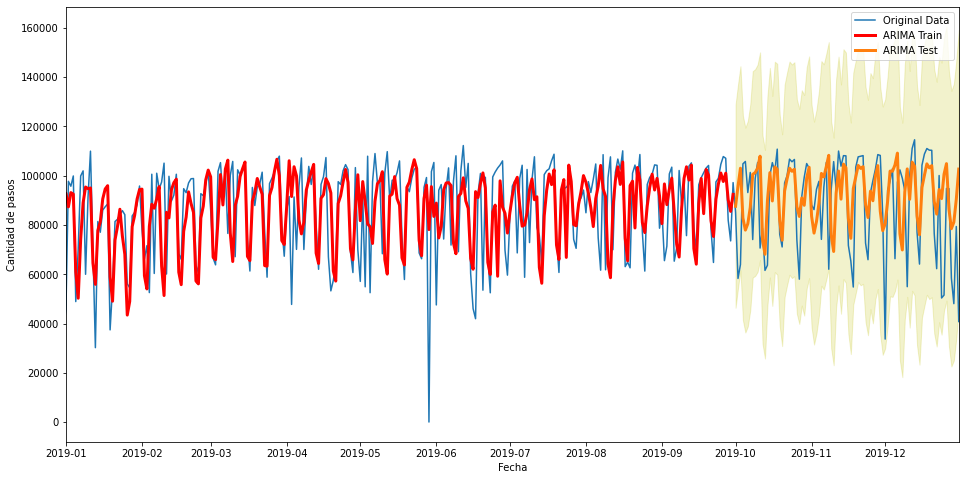

In [108]:
yd_train_pred = sarima_dia.predict('2017-01-01', '2019-09-30')
yd_test_pred = sarima_dia.predict('2019-10-01', '2019-12-31')
intervalo = sarima_dia.get_forecast("2019-12-31").conf_int()

plt.plot(dataset_illia_dia.drop(["fecha_numero"], axis=1), label="Original Data")
plt.plot(Xd_train.index, yd_train_pred, lw = 3, label = 'ARIMA Train', color="r")
plt.plot(Xd_test.index, yd_test_pred, lw = 3, label = 'ARIMA Test')
plt.fill_between(intervalo.index,
                intervalo.iloc[:, 0],
                intervalo.iloc[:, 1], color='y', alpha=.2)

plt.xlabel('Fecha')
plt.ylabel('Cantidad de pasos')
plt.legend()

plt.xlim(pd.to_datetime("1st of jan, 2019"), pd.to_datetime("31st of dec, 2019"))
plt.show()

Se observa inmediatamente que el modelo SARIMAX tiene picos y caídas más alargadas, ya que al tener en cuenta la estacionalidad se ajusta de mejor forma a dichos cambios.

In [109]:
sarima_dia.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                         SARIMAX Results                                          
==================================================================================================
Dep. Variable:                             cantidad_pasos   No. Observations:                 1003
Model:             SARIMAX(0, 1, 1)x(1, 1, [1, 2, 3], 28)   Log Likelihood               -9873.467
Date:                                    Sun, 12 Sep 2021   AIC                          19758.934
Time:                                            23:04:54   BIC                          19787.668
Sample:                                        01-01-2017   HQIC                         19769.918
                                             - 09-30-2019                                         
Covariance Type:                                      opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9318      0.023    -40.676      0.000      -0.977      -0.887
ar.S.L28       0.0526      0.733      0.072      0.943      -1.384       1.489
ma.S.L28      -0.8868      0.730     -1.214      0.225      -2.318       0.545
ma.S.L56       0.1260      0.602      0.209      0.834      -1.053       1.306
ma.S.L84      -0.0568      0.063     -0.900      0.368      -0.181       0.067
sigma2      4.421e+08   1.37e-08   3.23e+16      0.000    4.42e+08    4.42e+08
===================================================================================
Ljung-Box (L1) (Q):                  25.51   Jarque-Bera (JB):              2968.06
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.70   Skew:                            -1.77
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.11e+32. Standard errors may be unstable.
"""

El AIC del SARIMAX es de 19774 identico al ARIMA. 

In [110]:
mean_squared_error(yd_train, yd_train_pred, squared=False)

15789.882800602594

Con un AIC parecido no es de extrañar que el error haya disminuido en igual proporción.

<a href="#0"><font size="1">Volver a contenidos</font></a>

## 4. Próximos pasos<a id="prox"></a>

En el análisis exploratorio de los datos, se destacó que la estación Illia no tiene una clara tendencia de los datos y en el análisis de residuales se mostró la gran variación de los datos al final del periodo analizado. Por esto consideramos necesario incorporar datos adicionales para comparar los modelos de predicción. 

Para ello utilizaremos la variable de día de la semana, debido a que esta variable está bastante diferenciada, recordar lo encontrado en el EDA: martes y sábados poseen la mayor cantidad de pasos vehiculares.

Así que el primer paso es incorporar dicha variable en los datos elegidos:

In [236]:
# Agrupación por fecha y hora del día
dataset_illia2 = illia_preprocess.groupby(["fecha"])["cantidad_pasos"].sum().reset_index()

In [237]:
# Indexar las fechas
dataset_illia2.set_index("fecha",inplace=True)

In [238]:
# Resamplear a datos por dia
dataset_illia2 = dataset_illia2.resample("D").sum()

In [244]:
# Se adiciona el dia de forma numerica
dataset_illia2['dia'] = pd.Series(dataset_illia2.index).dt.dayofweek.values

Para la predicción utilizaremos la librería [Prophet](https://facebook.github.io/prophet/docs/quick_start.html) que funciona similar a sklearn, utilizando métodos *fit* y *predict*. 

Prophet requiere siempre un dataset de entrada con únicamente dos columns, *ds* y *y*, que hacen referencia a *datestamp* en formato YYYY-MM-DD para fechas o YYYY-MM-DD HH:MM:SS para estampas de tiempos. La columna *y* por su parte corresponde al valor númerico que se desea predecir en un futuro.

In [114]:
# Para instalar prophet fue necesario utilizar el power sheel de anaconda y correr las siguientes líneas:
# conda install -c anaconda ephem
# conda install -c conda-forge pystan
# conda install -c conda-forge fbprophet
from fbprophet import Prophet 

In [246]:
# Se verifica que la variable a adicionar tenga balance en sus datos
dataset_illia2['dia'].value_counts()

0    157
1    157
6    157
2    156
3    156
4    156
5    156
Name: dia, dtype: int64

In [247]:
model = Prophet(daily_seasonality=True) # Crear el tipo de modelo
dataset_prophet = dataset_illia2.reset_index().rename(columns={'fecha':'ds','cantidad_pasos':'y'})

In [248]:
dataset_prophet.shape # Dimensión del dataset

(1095, 3)

In [249]:
dataset_prophet.head() # Observar el dataset modificado

,ds,y,dia
0,2017-01-01,42577,6
1,2017-01-02,82228,0
2,2017-01-03,85219,1
3,2017-01-04,88351,2
4,2017-01-05,92300,3


Se adiciona un regresor lineal que permite ayudar a incorporar una variable extra a prophet (recordar que normalmente solo admite *ds* y *y*)

In [250]:
model.add_regressor('dia',standardize=False,mode='multiplicative')
prophet_train = dataset_prophet[dataset_prophet.ds<'2019-09-30'] # Se eligen los datos de entrenamiento
model.fit(prophet_train) # Se modelan los datos de entrenamiento

Las predicciones son realizadas con una columna *ds* que contiene las fechas para las cuales las predicciones serán hechas. Puede extenderse el dataframe hacia el futuro especificando la cantidad de días a adicionar utilizando el método Prophet.make_future_dataframe.

In [251]:
# Días a predecir
diff = (pd.to_datetime('2019-12-31')-pd.to_datetime('2019-09-30')).days
diff

92

In [267]:
prediction = model.make_future_dataframe(periods=diff, freq='D') # Dataset a predecir

Ahora es necesario incluir la variable dia dentro del dataset a predecir:

In [268]:
prediction['dia'] = dataset_prophet['dia'] # Añadir día

In [269]:
forecast = model.predict(prediction)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,yhat
0,2017-01-01,36046.260927,28391.721401,60707.453703,36046.260927,36046.260927,-89359.781816,-89359.781816,-89359.781816,-3998.065018,...,2.714108,2.714108,2.714108,-75698.626103,-75698.626103,-75698.626103,-9663.090694,-9663.090694,-9663.090694,44519.935539
1,2017-01-02,36055.590654,57932.864243,91105.786633,36055.590654,36055.590654,39137.796443,39137.796443,39137.796443,-3998.065018,...,0.000000,0.000000,0.000000,53140.675428,53140.675428,53140.675428,-10004.813967,-10004.813967,-10004.813967,75193.387097
2,2017-01-03,36064.920381,62627.780412,98087.151153,36064.920381,36064.920381,26932.118735,26932.118735,26932.118735,-3998.065018,...,0.452351,0.452351,0.452351,41195.382712,41195.382712,41195.382712,-10265.198958,-10265.198958,-10265.198958,79311.055817
3,2017-01-04,36074.250108,63146.615781,97652.279261,36074.250108,36074.250108,12131.818462,12131.818462,12131.818462,-3998.065018,...,0.904703,0.904703,0.904703,26572.698430,26572.698430,26572.698430,-10442.814950,-10442.814950,-10442.814950,80842.542601
4,2017-01-05,36083.579835,64646.254962,100157.581662,36083.579835,36083.579835,-2687.271634,-2687.271634,-2687.271634,-3998.065018,...,1.357054,1.357054,1.357054,11848.471543,11848.471543,11848.471543,-10537.678159,-10537.678159,-10537.678159,82363.680193


In [270]:
# Dividir el dataset de predicciones en los intervalos elegidos de tiempo
y_train_pred_prophet= forecast[forecast.ds<'2019-09-30'].yhat
y_test_pred_prophet= forecast[forecast.ds>='2019-09-30'].yhat

In [290]:
# # Dividir los datos reales en los intervalos elegidos de tiempo
y_train_prophet= dataset_illia2[dataset_illia2.index<'2019-09-30'].iloc[:]
y_test_prophet= dataset_illia2[dataset_illia2.index>='2019-09-30'].iloc[0:-1]

In [293]:
rmse_train_prophet = mean_squared_error(y_train_prophet.cantidad_pasos.values, y_train_pred_prophet.values, squared=False)
print("RMSE Modelo Prophet con la variable día adicionada, entrenamiento:", round(rmse_train_prophet, 2))
rmse_test_prophet = mean_squared_error(y_test_prophet.cantidad_pasos.values, y_test_pred_prophet.values, squared=False)
print("RMSE Modelo Prophet con la variable día adicionada, prueba:", round(rmse_test_prophet, 2))

RMSE Modelo Prophet con la variable día adicionada, entrenamiento: 13608.82
RMSE Modelo Prophet con la variable día adicionada, prueba: 16977.68


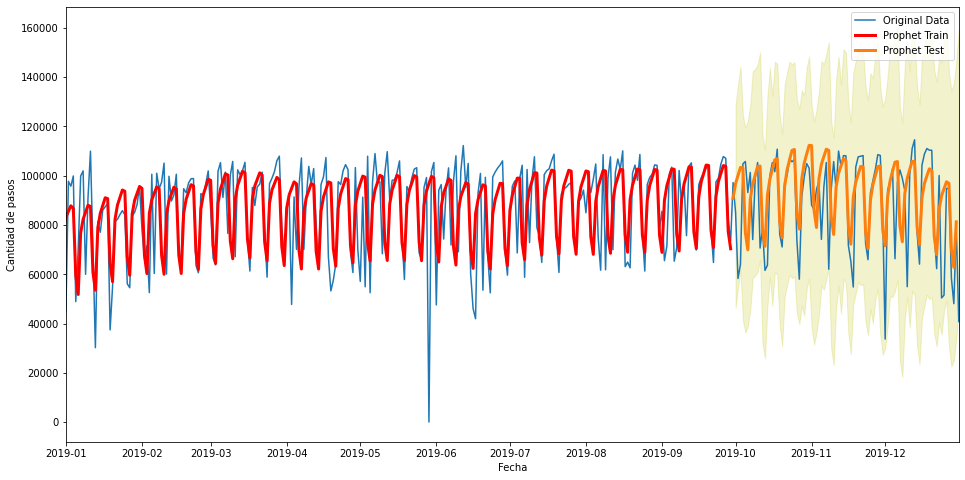

In [298]:
plt.plot(dataset_illia_dia.drop(["fecha_numero"], axis=1), label="Original Data")
plt.plot(dataset_illia2[dataset_illia2.index<'2019-09-30'].index, y_train_pred_prophet, lw = 3,
         label = 'Prophet Train', color="r")
plt.plot(dataset_illia2[dataset_illia2.index>='2019-09-30'][0:-1].index, y_test_pred_prophet, lw = 3, label = 'Prophet Test')
plt.fill_between(intervalo.index,
                intervalo.iloc[:, 0],
                intervalo.iloc[:, 1], color='y', alpha=.2)

plt.xlabel('Fecha')
plt.ylabel('Cantidad de pasos')
plt.legend()

plt.xlim(pd.to_datetime("1st of jan, 2019"), pd.to_datetime("31st of dec, 2019"))
plt.show()

Hubo una mejora bastante significativa del modelo en comparación a los anteriores en cuanto a la predicción de tendencia de los datos, los otros modelos predecian una tendencia de incremento, mientras este decrece de manera similar a los datos reales. A pesar de tener un mayor error cuadrático medio que el modelo ARIMA resampleado diariamente (RMSE 15789). 

Seguramente si se observaran uno o más meses posterior al 31 de diciembre del 2019 la métrica utilizada percibiría este último modelo como uno de más precisión.

<a href="#0"><font size="1">Volver a contenidos</font></a>

## 5. Conclusiones<a id="con"></a>

1. Cada gráfica se revisó y analizó en la celda contigua pero en general, la estación Illia mostraba un comportamiento irregular comparado a las otras estaciones, en cuanto a los valores en el tiempo y las distribuciones de los datos. Se compararon las estaciones más similares en cuanto a flujo vehicular para hacer más justa la comparación y se identificó que en general las estaciones tenían el menor flujo vehicular a inicio de año e iba incrementando gradualmente, seguro debido a la temporada de viajes, muchas personas salen de la ciudad y no hacen uso de estos peajes. 
2. La métrica escogida fue el error cuadrático medio ya que nos da un buen valor de comparación entre modelos y que tanto se alejan de los resultados reales.
3. A pesar de optimizar los modelos e incluir modelos matemáticos más robustos el desempeño de ambos fue muy cercano, los modelos ARIMA y SARIMAX obtuvieron un error muy similar, y se desempeñan de manera mnuy similar debido a la similitud en los valores de AIC. En general ambos se desempeñaron mucho mejor al benchmark y a pesar de tener errores de 16 mil teniendo en cuenta que Illia es la estación más cambiante y que la desviación estandar de los datos era tan grande, para un rango de 200 mil error de 16mil, sería casi de un 8% entonces, podría ser útil para estimar flujo de carros en el futuro cercano. Aunque entre más datos se usen para entrenar mejor.
4. Algo que afecto demasiado a los modelos fue el cambio de comportamiento de los datos luego del 2019, esta inestabilidad hizo que los modelos se desempeñaran mal o con buena tendencia pero algo desfasados.
5. Apesar de utilizar la librería prophet para incorporar una variable adicional al modelo, no se logró un mejor resultado en cuanto al error cuadrático medio. Sin embargo, hubo una mejora bastante significativa en cuanto a la predicción de tendencia de los datos. Mientras los otros modelos predecian una tendencia incremental al final del periodo, este último decreció de manera similar a los datos reales. Adicionalmente, se sugiere incorporar datos de más años (antes o después del periodo utilizado) para mejorar los modelos. 

En general, el año 2019 tuvo una gran variación de los datos que se ve claramente en el análisis de residuales, por lo cual predecir en este año fue bastante retador.